# **Bài Thực Hành Số 03: MONTE CARLO METHODS TRONG HỌC TĂNG CƯỜNG**
**Học phần:** *Học Tăng Cường Cơ Bản*

**Sinh viên:** *Lê Thị Thúy*

**Mã sinh viên:** *22010846*

**Mục tiêu:**
* Sinh episode từ một policy;
* Lưu đầy đủ trajectory;
* Tính return cho từng timestep;
* Cài đặt First-Visit MC prediction;
* Cài đặt Every-Visit MC prediction;
* Ước lượng V(s);
* Ước lượng Q(s,a);
* Xây dựng epsilon-greedy policy;
* Cài đặt Monte Carlo control;
* Đánh giá policy học được;
* So sánh Monte Carlo với random policy;
* Quan sát sự hội tụ khi tăng số episode.

## **Chuẩn bị môi trường và thư viện**
STUDENT_ID = "22010846"

STUDENT_NAME = "Le Thi Thuy"

MAIN_ENV = "Blackjack-v1"

OPTIONAL_ENVS = [
    "MountainCar-v0",
]


In [2]:
!pip install -q "gymnasium[toy-text,classic-control]"
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from collections import defaultdict



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
print("Gymnasium:", gym.__version__)
print("NumPy:", np.__version__)


Gymnasium: 1.3.0
NumPy: 2.4.2


## **Tạo cấu trúc thư mục Lab03**

In [1]:
import os


def find_lab_root(folder_name="Lab03"):
    """
    Tìm thư mục gốc Lab03
    """
    cwd = os.path.abspath(os.getcwd())

    if os.path.basename(cwd) == folder_name:
        return cwd

    parent = cwd
    while True:
        if os.path.basename(parent) == folder_name:
            return parent
        new_parent = os.path.dirname(parent)
        if new_parent == parent:  # đã lên tới ổ đĩa gốc mà không thấy
            break
        parent = new_parent

    return os.path.join(cwd, folder_name)


BASE = find_lab_root("Lab03")

folders = [
    BASE,
    f"{BASE}/src",
    f"{BASE}/notebooks",
    f"{BASE}/figures",
    f"{BASE}/data",
]
for f in folders:
    os.makedirs(f, exist_ok=True)

files = [
    f"{BASE}/README.md",
    f"{BASE}/requirements.txt",
    f"{BASE}/src/mc_utils.py",
    f"{BASE}/src/main.py",
    f"{BASE}/data/README.md",
] + [f"{BASE}/src/bai{str(i).zfill(2)}.py" for i in range(1, 35)]

for f in files:
    if not os.path.exists(f):
        open(f, "a").close()

print("Thư mục làm việc hiện tại (cwd):", os.getcwd())
print("Đã xác định BASE (Lab03) tại:", BASE)
print("Đã tạo cấu trúc thư mục Lab03")

Thư mục làm việc hiện tại (cwd): c:\Users\LENOVO\Downloads\Học Tăng Cường Cơ Bản\Thực Hành\Lab03
Đã xác định BASE (Lab03) tại: c:\Users\LENOVO\Downloads\Học Tăng Cường Cơ Bản\Thực Hành\Lab03
Đã tạo cấu trúc thư mục Lab03


## **Thư Viện Dùng Chung**

**Mục đích:** Đóng gói các hàm dùng chung để các file bai01.py đến bai36.py có thể import lại

In [4]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "mc_utils.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''import gymnasium as gym
import numpy as np
from collections import defaultdict

def generate_episode(env, policy=None, seed=None):
    """Sinh 1 episode từ môi trường theo policy cho trước."""
    state, _ = env.reset(seed=seed)
    terminated = False
    truncated = False
    episode = []
    while not (terminated or truncated):
        if policy is None:
            action = env.action_space.sample()
        else:
            action = policy(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        episode.append((state, action, reward))
        state = next_state
    return episode

def compute_returns(rewards, gamma=1.0):
    """Tính discounted return G_t từ danh sách rewards từ cuối episode trở về đầu."""
    returns = [0.0] * len(rewards)
    g = 0.0
    for t in reversed(range(len(rewards))):
        g = rewards[t] + gamma * g
        returns[t] = g
    return returns
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)


## **Bài Tập Phần A: Làm Quen Với Episodic Environment**

### **Bài 1. Tạo Blackjack-v1**
Khởi tạo môi trường Blackjack-v1, thực hiện reset() để lấy quan sát đầu tiên và kiểm tra không gian trạng thái/hành động.  
**Mục đích:** Hiểu cấu trúc khởi tạo môi trường chuẩn trong Gymnasium.

In [5]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai01.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 1: Tạo Blackjack-v1"""
import gymnasium as gym

def main():
    env = gym.make("Blackjack-v1")
    obs, info = env.reset(seed=42)
    print("Observation ban đầu:", obs)
    print("Info:", info)
    print("Observation Space:", env.observation_space)
    print("Action Space:", env.action_space)
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Observation ban đầu: (15, 2, 0)
Info: {}
Observation Space: Tuple(Discrete(32), Discrete(11), Discrete(2))
Action Space: Discrete(2)


### **Bài 2: Phân tích observation**
Lặp qua 10 episode khác nhau, lấy observation và giải thích 3 thành phần: player sum, dealer showing card, usable ace.   
**Mục đích:** Nắm rõ cấu trúc dữ liệu quan sát của game Blackjack.

In [3]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai02.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 2: Phân tích observation"""
import gymnasium as gym

# Môi trường Blackjack-v1 trả về observation là một tuple gồm 3 thành phần:
# 1. player_sum (int): Tổng điểm hiện tại của người chơi (thường từ 4 đến 21 điểm).
# 2. dealer_card (int): Lá bài ngửa của nhà cái (dealer) đang mở trên bàn (từ 1 đến 10, trong đó 1 đại diện cho con Ách/Ace).
# 3. usable_ace (bool/int): Cờ đánh dấu người chơi có con Ách linh hoạt (Usable Ace) hay không:
#    - 1 (hoặc True): Người chơi sở hữu ít nhất 1 lá Ách đang được tính là 11 điểm mà tổng điểm không vượt quá 21.
#    - 0 (hoặc False): Người chơi không có lá Ách linh hoạt (không có Ách hoặc Ách bắt buộc phải tính là 1 điểm).

def main():
    env = gym.make("Blackjack-v1")
    print("In 10 observation từ 10 episode ngẫu nhiên:")
    for i in range(10):
        obs, _ = env.reset(seed=i)
        
        # Giải nén tuple observation thành 3 biến tương ứng
        player_sum, dealer_card, usable_ace = obs
        
        print(f"Episode {i+1:2d}: Player Sum = {player_sum:2d} | Dealer Card = {dealer_card:2d} | Usable Ace = {usable_ace}")
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

In 10 observation từ 10 episode ngẫu nhiên:
Episode  1: Player Sum = 11 | Dealer Card = 10 | Usable Ace = 0
Episode  2: Player Sum = 20 | Dealer Card =  7 | Usable Ace = 0
Episode  3: Player Sum =  6 | Dealer Card = 10 | Usable Ace = 0
Episode  4: Player Sum =  7 | Dealer Card = 10 | Usable Ace = 0
Episode  5: Player Sum = 17 | Dealer Card = 10 | Usable Ace = 0
Episode  6: Player Sum = 21 | Dealer Card =  9 | Usable Ace = 1
Episode  7: Player Sum = 12 | Dealer Card =  6 | Usable Ace = 0
Episode  8: Player Sum = 19 | Dealer Card = 10 | Usable Ace = 0
Episode  9: Player Sum = 14 | Dealer Card = 10 | Usable Ace = 0
Episode 10: Player Sum = 14 | Dealer Card =  6 | Usable Ace = 0


### **Bài 3. Phân tích action**
Kiểm tra env.action_space và tạo từ điển ACTION_NAMES map ID hành động sang tên gọi thực tế.   
**Mục đích:** Xác định rõ ý nghĩa của hành động Stick (0) và Hit (1).

In [4]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai03.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 3: Phân tích action"""
import gymnasium as gym

ACTION_NAMES = {
    0: "Stick (Dằn bài / Ngưng rút)",
    1: "Hit (Rút thêm bài)"
}

def main():
    env = gym.make("Blackjack-v1")
    print("Action Space:", env.action_space)
    print("Số lượng hành động khả thi:", env.action_space.n)
    print("Danh sách hành động:")
    for action_id, action_name in ACTION_NAMES.items():
        print(f"  ID {action_id}: {action_name}")
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Action Space: Discrete(2)
Số lượng hành động khả thi: 2
Danh sách hành động:
  ID 0: Stick (Dằn bài / Ngưng rút)
  ID 1: Hit (Rút thêm bài)


### **Bài 4. Một episode ngẫu nhiên**

Chạy 1 episode ngẫu nhiên (random policy) và in chi tiết từng bước tương tác bao gồm trạng thái, hành động, phần thưởng, trạng thái kế tiếp và cờ kết thúc.

**Mục đích:** Trực quan hóa luồng chuyển trạng thái thực tế và quá trình thu thập phần thưởng trong một episode.

In [6]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai04.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 4: Một episode ngẫu nhiên"""
import gymnasium as gym

def main():
    env = gym.make("Blackjack-v1")
    state, _ = env.reset(seed=42)
    terminated = False
    truncated = False
    step = 0
    print(f"Trạng thái bắt đầu (state): {state}\\n")
    
    while not (terminated or truncated):
        step += 1
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, _ = env.step(action)
        
        print(f"--- Bước {step} ---")
        print(f"  state      : {state}")
        print(f"  action     : {action}")
        print(f"  reward     : {reward}")
        print(f"  next_state : {next_state}")
        print(f"  terminated : {terminated}")
        print(f"  truncated  : {truncated}\\n")
        
        state = next_state
        
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Trạng thái bắt đầu (state): (15, 2, 0)

--- Bước 1 ---
  state      : (15, 2, 0)
  action     : 1
  reward     : -1.0
  next_state : (25, 2, 0)
  terminated : True
  truncated  : False



### **Bài 5. Lưu episode**
Gọi hàm generate_episode từ mc_utils.py để sinh và lưu lại trajectory dưới dạng danh sách các tuple (state, action, reward).   
**Mục đích:** Đóng gói quá trình thu thập dữ liệu episode thành một hàm tái sử dụng trong file src/mc_utils.py

In [7]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai05.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 5: Lưu episode"""
import gymnasium as gym
from mc_utils import generate_episode

def main():
    env = gym.make("Blackjack-v1")
    ep = generate_episode(env, seed=10)
    print("Trajectory thu được (state, action, reward):")
    for idx, step in enumerate(ep):
        print(f"  Bước {idx+1}: {step}")
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Trajectory thu được (state, action, reward):
  Bước 1: ((7, 10, 0), np.int64(0), -1.0)


## **Bài Tập Phần B: Return Từ Episode**

### **Bài 6. Chuỗi reward**
Tách riêng danh sách phần thưởng rewards từ episode vừa sinh, tính độ dài chuỗi tương tác và tổng reward tích lũy.   
**Mục đích:** Trích xuất phần thưởng thô để làm đầu vào cho việc tính toán return.

In [8]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai06.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 6: Chuỗi reward"""
import gymnasium as gym
from mc_utils import generate_episode

def main():
    env = gym.make("Blackjack-v1")
    episode = generate_episode(env, seed=2026)
    rewards = [step[2] for step in episode]
    print("Độ dài Episode:", len(episode))
    print("Danh sách Rewards:", rewards)
    print("Tổng Reward (Total Reward):", sum(rewards))
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Độ dài Episode: 2
Danh sách Rewards: [0.0, -1.0]
Tổng Reward (Total Reward): -1.0


### **Bài 7. Tính return từ cuối episode**
 Gọi hàm compute_returns trong mc_utils.py để tính dãy return $G_t$ bằng cách duyệt ngược từ bước cuối cùng về bước đầu tiên.   
 **Mục đích:** Cài đặt công thức tính return chiết khấu $G_t = R_{t+1} + \gamma G_{t+1}$ đảm bảo độ phức tạp tuyến tính $O(T)$. 

In [9]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai07.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 7: Tính return từ cuối episode"""
from mc_utils import compute_returns

def main():
    sample_rewards = [0, 0, 1]
    gamma = 0.9
    g_list = compute_returns(sample_rewards, gamma=gamma)
    print("Chuỗi Rewards mẫu:", sample_rewards)
    print(f"Returns thu được (gamma={gamma}):", g_list)

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Chuỗi Rewards mẫu: [0, 0, 1]
Returns thu được (gamma=0.9): [0.81, 0.9, 1.0]


### **Bài 8. Kiểm tra return**
Thử nghiệm hàm compute_returns trên dãy reward giả lập [0, 0, 1] với các giá trị $\gamma \in \{1.0, 0.9, 0.5\}$.   
**Mục đích:** Đánh giá sự giảm giá trị của phần thưởng tương lai khi thay đổi hệ số chiết khấu $\gamma$.

In [10]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai08.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 8: Kiểm tra return"""
from mc_utils import compute_returns

def main():
    rewards = [0, 0, 1]
    gammas = [1.0, 0.9, 0.5]
    print(f"Chuỗi reward mẫu: {rewards}")
    for gamma in gammas:
        ret = compute_returns(rewards, gamma)
        print(f"Gamma = {gamma:<4} -> Returns G_t: {ret}")

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Chuỗi reward mẫu: [0, 0, 1]
Gamma = 1.0  -> Returns G_t: [1.0, 1.0, 1.0]
Gamma = 0.9  -> Returns G_t: [0.81, 0.9, 1.0]
Gamma = 0.5  -> Returns G_t: [0.25, 0.5, 1.0]


### **Bài 9. Gắn return vào trajectory**
Tích hợp chuỗi return $G_t$ vừa tính được vào từng bước tương tác để tạo thành trajectory dạng (state, action, reward, G_t). 

**Mục đích:** Xây dựng cấu trúc dữ liệu phục vụ giai đoạn cập nhật giá trị trong thuật toán Monte Carlo Prediction.

In [11]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai09.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 9: Gắn return vào trajectory"""
import gymnasium as gym
from mc_utils import generate_episode, compute_returns

def main():
    env = gym.make("Blackjack-v1")
    raw_episode = generate_episode(env, seed=15)
    rewards = [item[2] for item in raw_episode]
    returns = compute_returns(rewards, gamma=0.95)
    
    full_trajectory = [
        (raw_episode[i][0], raw_episode[i][1], raw_episode[i][2], returns[i])
        for i in range(len(raw_episode))
    ]
    
    print("Trajectory chứa Return (state, action, reward, G_t):")
    for step in full_trajectory:
        print(f"  {step}")
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Trajectory chứa Return (state, action, reward, G_t):
  ((20, 10, 0), np.int64(1), -1.0, -1.0)


### **Bài 10. So sánh gamma**
Chạy 1000 episode ngẫu nhiên và tính trung bình $G_0$ thu được ứng với các mức $\gamma \in \{0.5, 0.8, 0.9, 0.99, 1.0\}$.   
**Mục đích:** Quan sát sự thay đổi giá trị return kỳ vọng tại bước khởi đầu dưới tác động của hệ số chiết khấu $\gamma$.

Kết quả trung bình G_0 theo gamma:
Gamma = 0.5 : Mean G_0 = -0.3219
Gamma = 0.8 : Mean G_0 = -0.3790
Gamma = 0.9 : Mean G_0 = -0.3681
Gamma = 0.99: Mean G_0 = -0.3865
Gamma = 1.0 : Mean G_0 = -0.3950

Đã lưu biểu đồ tại: .\figures\gamma_comparison.png
Figure(800x500)


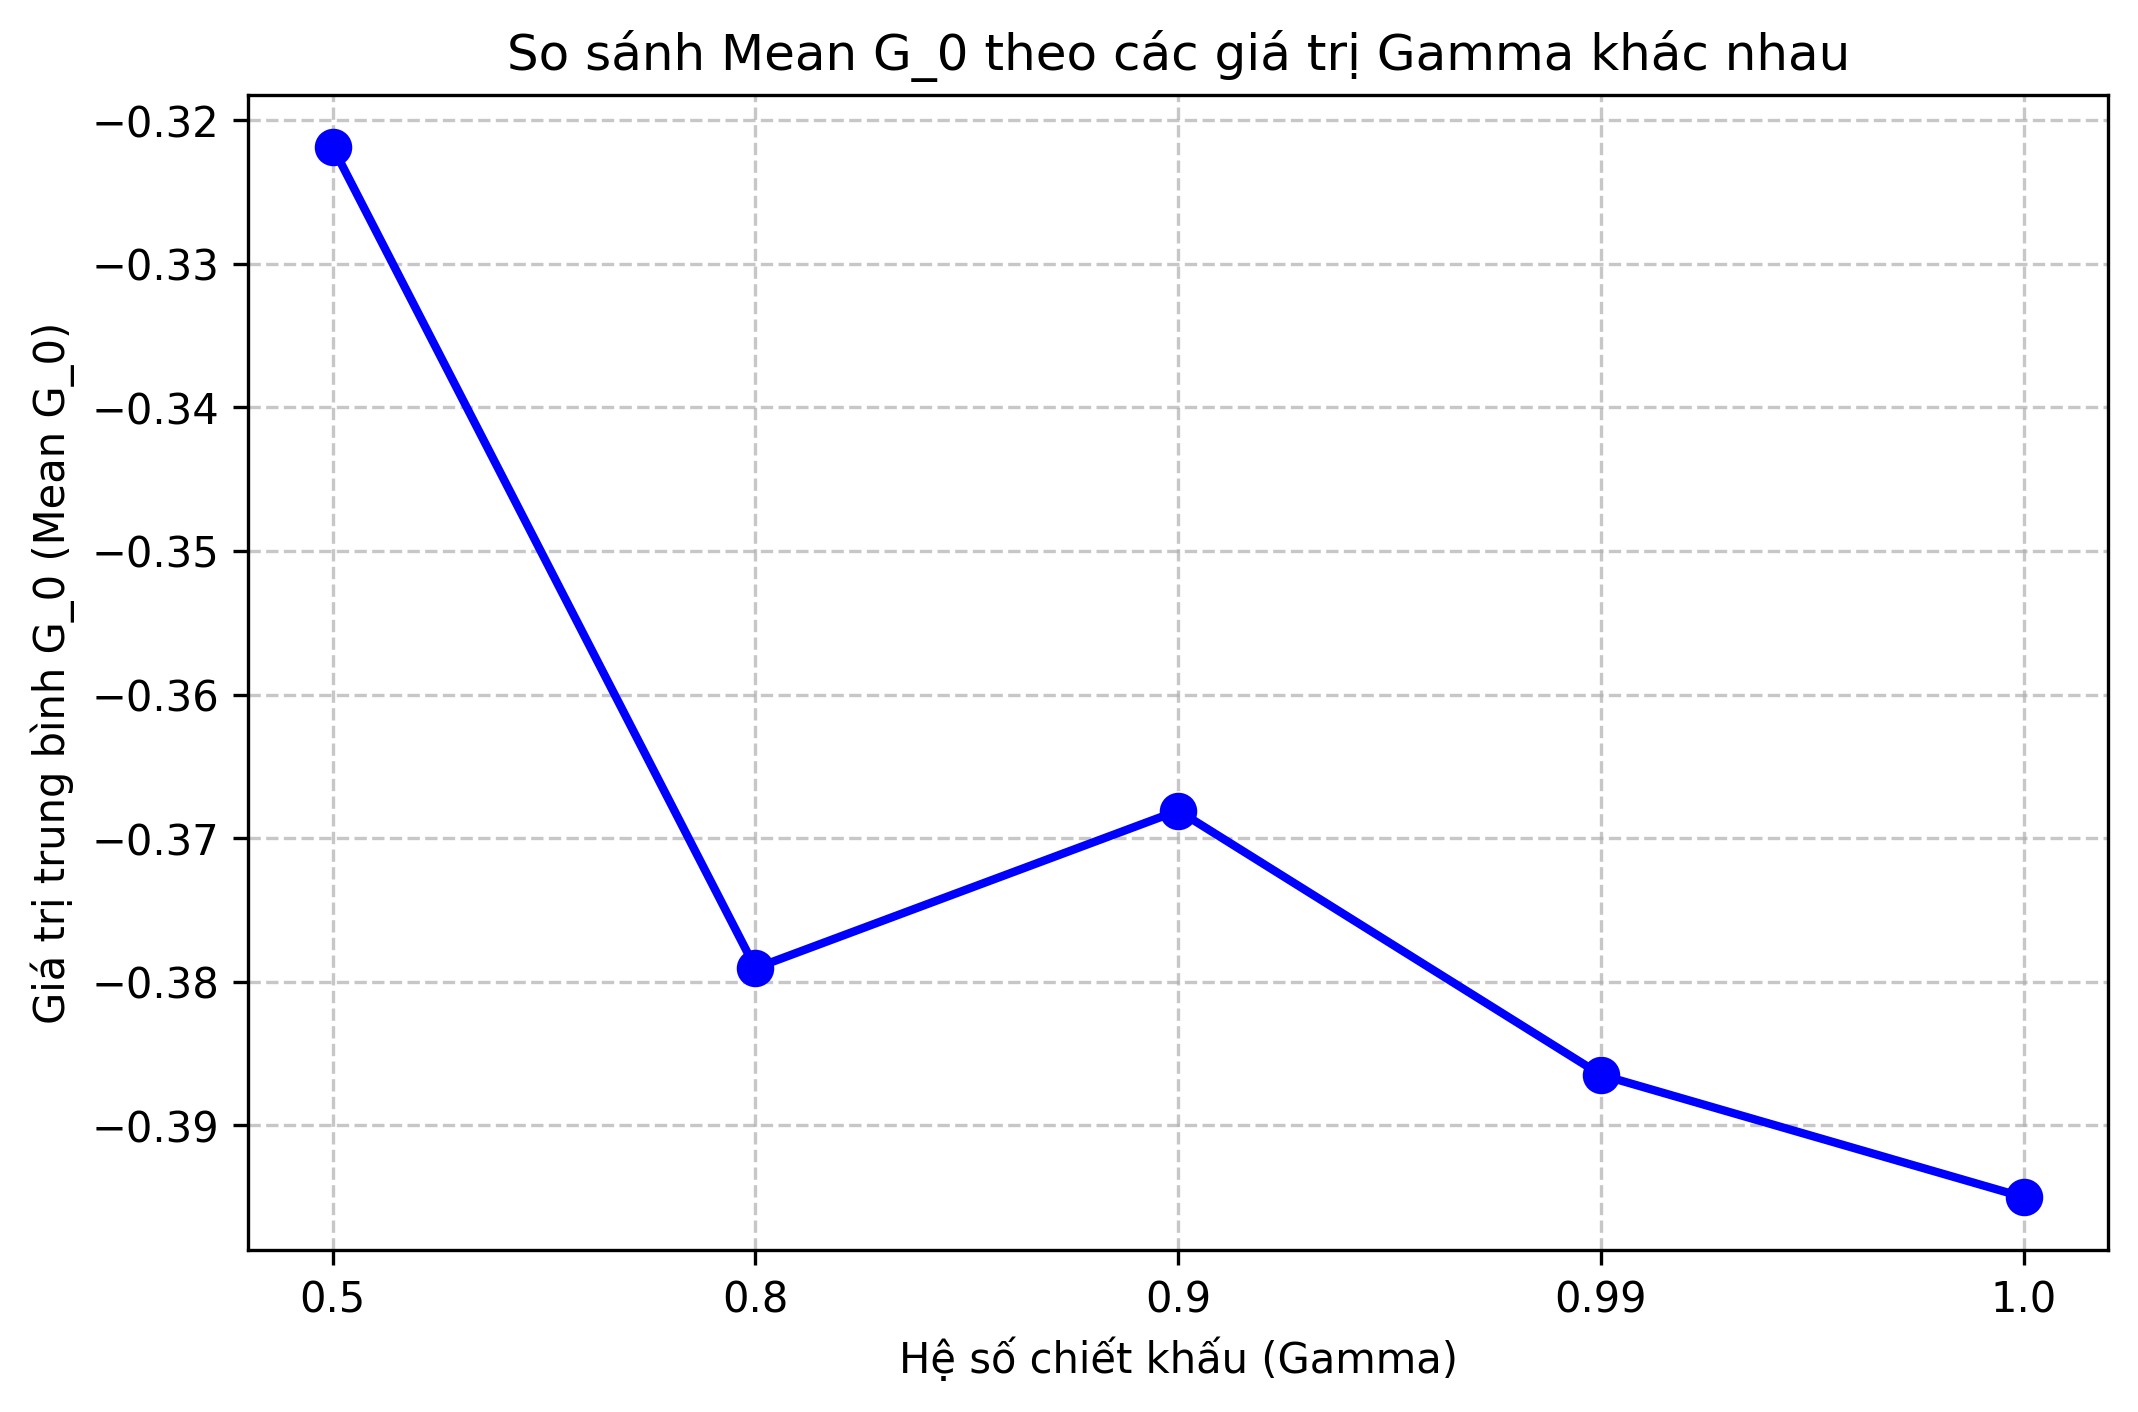

In [15]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai10.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 10: So sánh gamma và vẽ biểu đồ"""
import os
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from mc_utils import compute_returns

def main():
    env = gym.make("Blackjack-v1")
    gammas = [0.5, 0.8, 0.9, 0.99, 1.0]
    n_episodes = 1000
    mean_g0 = []
    
    for gamma in gammas:
        g0_list = []
        for ep in range(n_episodes):
            state, _ = env.reset(seed=ep)
            terminated = False
            truncated = False
            rewards = []
            while not (terminated or truncated):
                action = env.action_space.sample()
                _, reward, terminated, truncated, _ = env.step(action)
                rewards.append(reward)
            g0_list.append(compute_returns(rewards, gamma)[0] if rewards else 0.0)
        mean_g0.append(np.mean(g0_list))
        
    print("Kết quả trung bình G_0 theo gamma:")
    for gamma, val in zip(gammas, mean_g0):
        print(f"Gamma = {gamma:<4}: Mean G_0 = {val:.4f}")
    
    # Tạo thư mục figures nếu chưa tồn tại
    fig_dir = os.path.join(".", "figures")
    os.makedirs(fig_dir, exist_ok=True)
    
    # Vẽ biểu đồ so sánh Mean G_0 theo Gamma
    plt.figure(figsize=(8, 5))
    plt.plot([str(g) for g in gammas], mean_g0, marker='o', color='b', linewidth=2, markersize=8)
    plt.title("So sánh Mean G_0 theo các giá trị Gamma khác nhau")
    plt.xlabel("Hệ số chiết khấu (Gamma)")
    plt.ylabel("Giá trị trung bình G_0 (Mean G_0)")
    plt.grid(True, linestyle="--", alpha=0.7)
    
    # Lưu biểu đồ vào thư mục figures/
    output_fig_path = os.path.join(fig_dir, "gamma_comparison.png")
    plt.savefig(output_fig_path, dpi=300, bbox_inches="tight")
    print(f"\\nĐã lưu biểu đồ tại: {output_fig_path}")
    
    # Hiển thị biểu đồ khi chạy script
    plt.show()
    
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

# Thực thi file script
!python "{file_path}"

# Show ảnh ra notebook ngay lập tức nếu lệnh !python không tự render cửa sổ GUI
from IPython.display import Image, display
display(Image(filename="figures/gamma_comparison.png"))

## **Bài Tập Phần C: Monte Carlo Prediction Cơ Bản**

### **Bài 11. Policy cố định** 
Định nghĩa chính sách stick_on_20_policy (ngừng rút bài khi tổng điểm $\ge 20$, ngược lại rút thêm bài).  
**Mục đích:** Xây dựng một chính sách cố định đơn giản để đánh giá hàm giá trị $V(s)$.

In [16]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai11.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 11: Policy cố định stick_on_20_policy"""
import os
import gymnasium as gym

def stick_on_20_policy(state):
    """
    State: (player_sum, dealer_card, usable_ace)
    Trả về:
      0 (Stick) nếu player_sum >= 20
      1 (Hit)   nếu player_sum < 20
    """
    player_sum, dealer_card, usable_ace = state
    if player_sum >= 20:
        return 0  # Stick
    return 1      # Hit

def main():
    env = gym.make("Blackjack-v1")
    state, _ = env.reset(seed=42)
    action = stick_on_20_policy(state)
    
    print(f"Kiểm tra Policy tại State {state}:")
    print(f"  -> Action được chọn: {action} ({'Stick' if action == 0 else 'Hit'})")
    
    # Cập nhật thêm policy này vào src/mc_utils.py để sử dụng ở các bài sau
    utils_path = os.path.join("src", "mc_utils.py")
    if os.path.exists(utils_path):
        with open(utils_path, "a", encoding="utf-8") as f:
            f.write("\\n\\ndef stick_on_20_policy(state):\\n    player_sum, dealer_card, usable_ace = state\\n    return 0 if player_sum >= 20 else 1\\n")
    
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Kiểm tra Policy tại State (15, 2, 0):
  -> Action được chọn: 1 (Hit)


### **Bài 12. Sinh 100 episode**
Sử dụng stick_on_20_policy để chạy 100 episode, đếm số trận thắng (win), thua (loss), hòa (draw) dựa trên phần thưởng cuối cùng và tính tỷ lệ tương ứng.   
**Mục đích:** Đánh giá sơ bộ hiệu năng thực tế của chiến thuật "chỉ dằn bài ở 20 điểm".

In [17]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai12.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 12: Sinh 100 episode với stick_on_20_policy"""
import gymnasium as gym
from mc_utils import generate_episode, stick_on_20_policy

def main():
    env = gym.make("Blackjack-v1")
    n_episodes = 100
    wins = 0
    losses = 0
    draws = 0
    
    for seed in range(n_episodes):
        ep = generate_episode(env, policy=stick_on_20_policy, seed=seed)
        final_reward = ep[-1][2]  # Phần thưởng ở bước cuối cùng
        if final_reward == 1.0:
            wins += 1
        elif final_reward == -1.0:
            losses += 1
        else:
            draws += 1
            
    print(f"Kết quả sau {n_episodes} episode:")
    print(f"  Thắng (Win) : {wins:3d} ({wins/n_episodes*100:.1f}%)")
    print(f"  Thua  (Loss): {losses:3d} ({losses/n_episodes*100:.1f}%)")
    print(f"  Hòa   (Draw): {draws:3d} ({draws/n_episodes*100:.1f}%)")
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Kết quả sau 100 episode:
  Thắng (Win) :  28 (28.0%)
  Thua  (Loss):  64 (64.0%)
  Hòa   (Draw):   8 (8.0%)


### **Bài 13. Thu thập return theo state**
Sử dụng defaultdict(list) để lưu trữ toàn bộ danh sách return $G_t$ thu được cho mỗi trạng thái xuất hiện qua 500 episode. 

**Mục đích:** Khởi tạo cấu trúc bộ nhớ thu thập dữ liệu phục vụ thuật toán Monte Carlo.

In [1]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai13.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 13: Thu thập return theo state"""
import gymnasium as gym
from collections import defaultdict
from mc_utils import generate_episode, compute_returns, stick_on_20_policy

def main():
    env = gym.make("Blackjack-v1")
    returns = defaultdict(list)
    n_episodes = 500
    
    for ep_idx in range(n_episodes):
        ep = generate_episode(env, policy=stick_on_20_policy, seed=ep_idx)
        rewards = [step[2] for step in ep]
        g_list = compute_returns(rewards, gamma=1.0)
        
        for idx, step in enumerate(ep):
            state = step[0]
            returns[state].append(g_list[idx])
            
    print(f"Đã thu thập dữ liệu qua {n_episodes} episode.")
    print(f"Tổng số trạng thái duy nhất đã xuất hiện: {len(returns)}")
    sample_state = list(returns.keys())[0]
    print(f"Ví dụ trạng thái {sample_state} đã thu thập {len(returns[sample_state])} lượt return. 5 return đầu: {returns[sample_state][:5]}")
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Đã thu thập dữ liệu qua 500 episode.
Tổng số trạng thái duy nhất đã xuất hiện: 206
Ví dụ trạng thái (11, 10, 0) đã thu thập 10 lượt return. 5 return đầu: [-1.0, 1.0, 1.0, -1.0, -1.0]


### **Bài 14. Ước lượng V(s)**
Tính $V(s) = \text{np.mean}(\text{returns}[s])$ cho tất cả các trạng thái đã xuất hiện và in ra giá trị $V(s)$ đại diện của 10 trạng thái.   
**Mục đích:** Thực hiện ước lượng hàm giá trị trạng thái theo nguyên lý trung bình mẫu Monte Carlo

In [2]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai14.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 14: Ước lượng V(s) bằng trung bình mẫu"""
import gymnasium as gym
import numpy as np
from collections import defaultdict
from mc_utils import generate_episode, compute_returns, stick_on_20_policy

def main():
    env = gym.make("Blackjack-v1")
    returns = defaultdict(list)
    n_episodes = 2000
    
    for ep_idx in range(n_episodes):
        ep = generate_episode(env, policy=stick_on_20_policy, seed=ep_idx)
        rewards = [step[2] for step in ep]
        g_list = compute_returns(rewards, gamma=1.0)
        
        for idx, step in enumerate(ep):
            state = step[0]
            returns[state].append(g_list[idx])
            
    # Tính V(s)
    V = {state: np.mean(ret) for state, ret in returns.items()}
    
    print(f"Đã tính toán V(s) cho {len(V)} trạng thái.")
    print("\\nGiá trị V(s) của 10 trạng thái ngẫu nhiên:")
    for state in list(V.keys())[:10]:
        print(f"  State {str(state):<18}: V(s) = {V[state]:.4f} (Số lượt mẫu: {len(returns[state])})")
        
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Đã tính toán V(s) cho 262 trạng thái.

Giá trị V(s) của 10 trạng thái ngẫu nhiên:
  State (11, 10, 0)       : V(s) = -0.2051 (Số lượt mẫu: 39)
  State (12, 10, 0)       : V(s) = -0.6575 (Số lượt mẫu: 73)
  State (13, 10, 0)       : V(s) = -0.5694 (Số lượt mẫu: 72)
  State (16, 10, 0)       : V(s) = -0.7976 (Số lượt mẫu: 84)
  State (20, 7, 0)        : V(s) = 0.9583 (Số lượt mẫu: 24)
  State (6, 10, 0)        : V(s) = -0.3333 (Số lượt mẫu: 12)
  State (14, 10, 0)       : V(s) = -0.6957 (Số lượt mẫu: 92)
  State (19, 10, 0)       : V(s) = -0.7818 (Số lượt mẫu: 110)
  State (7, 10, 0)        : V(s) = -0.5294 (Số lượt mẫu: 17)
  State (17, 10, 0)       : V(s) = -0.6346 (Số lượt mẫu: 104)


### **Bài 15. Theo dõi một state cụ thể**
Theo dõi giá trị ước lượng $V(s)$ của trạng thái mục tiêu target_state = (20, 10, False) theo mốc số lượng episode: 100, 500, 1000, 5000, 10000.

**Mục đích:** Minh họa tính chất hội tụ của phương pháp Monte Carlo theo Luật số lớn.

Theo dõi trạng thái mục tiêu (20, 10, False):
  Episode   100: V(state) = 0.4000 (Số lượt thăm: 10)
  Episode   500: V(state) = 0.3824 (Số lượt thăm: 34)
  Episode  1000: V(state) = 0.4722 (Số lượt thăm: 72)
  Episode  5000: V(state) = 0.4560 (Số lượt thăm: 307)
  Episode 10000: V(state) = 0.4131 (Số lượt thăm: 610)

Đã lưu biểu đồ hội tụ tại: .\figures\mc_convergence.png
Figure(800x500)


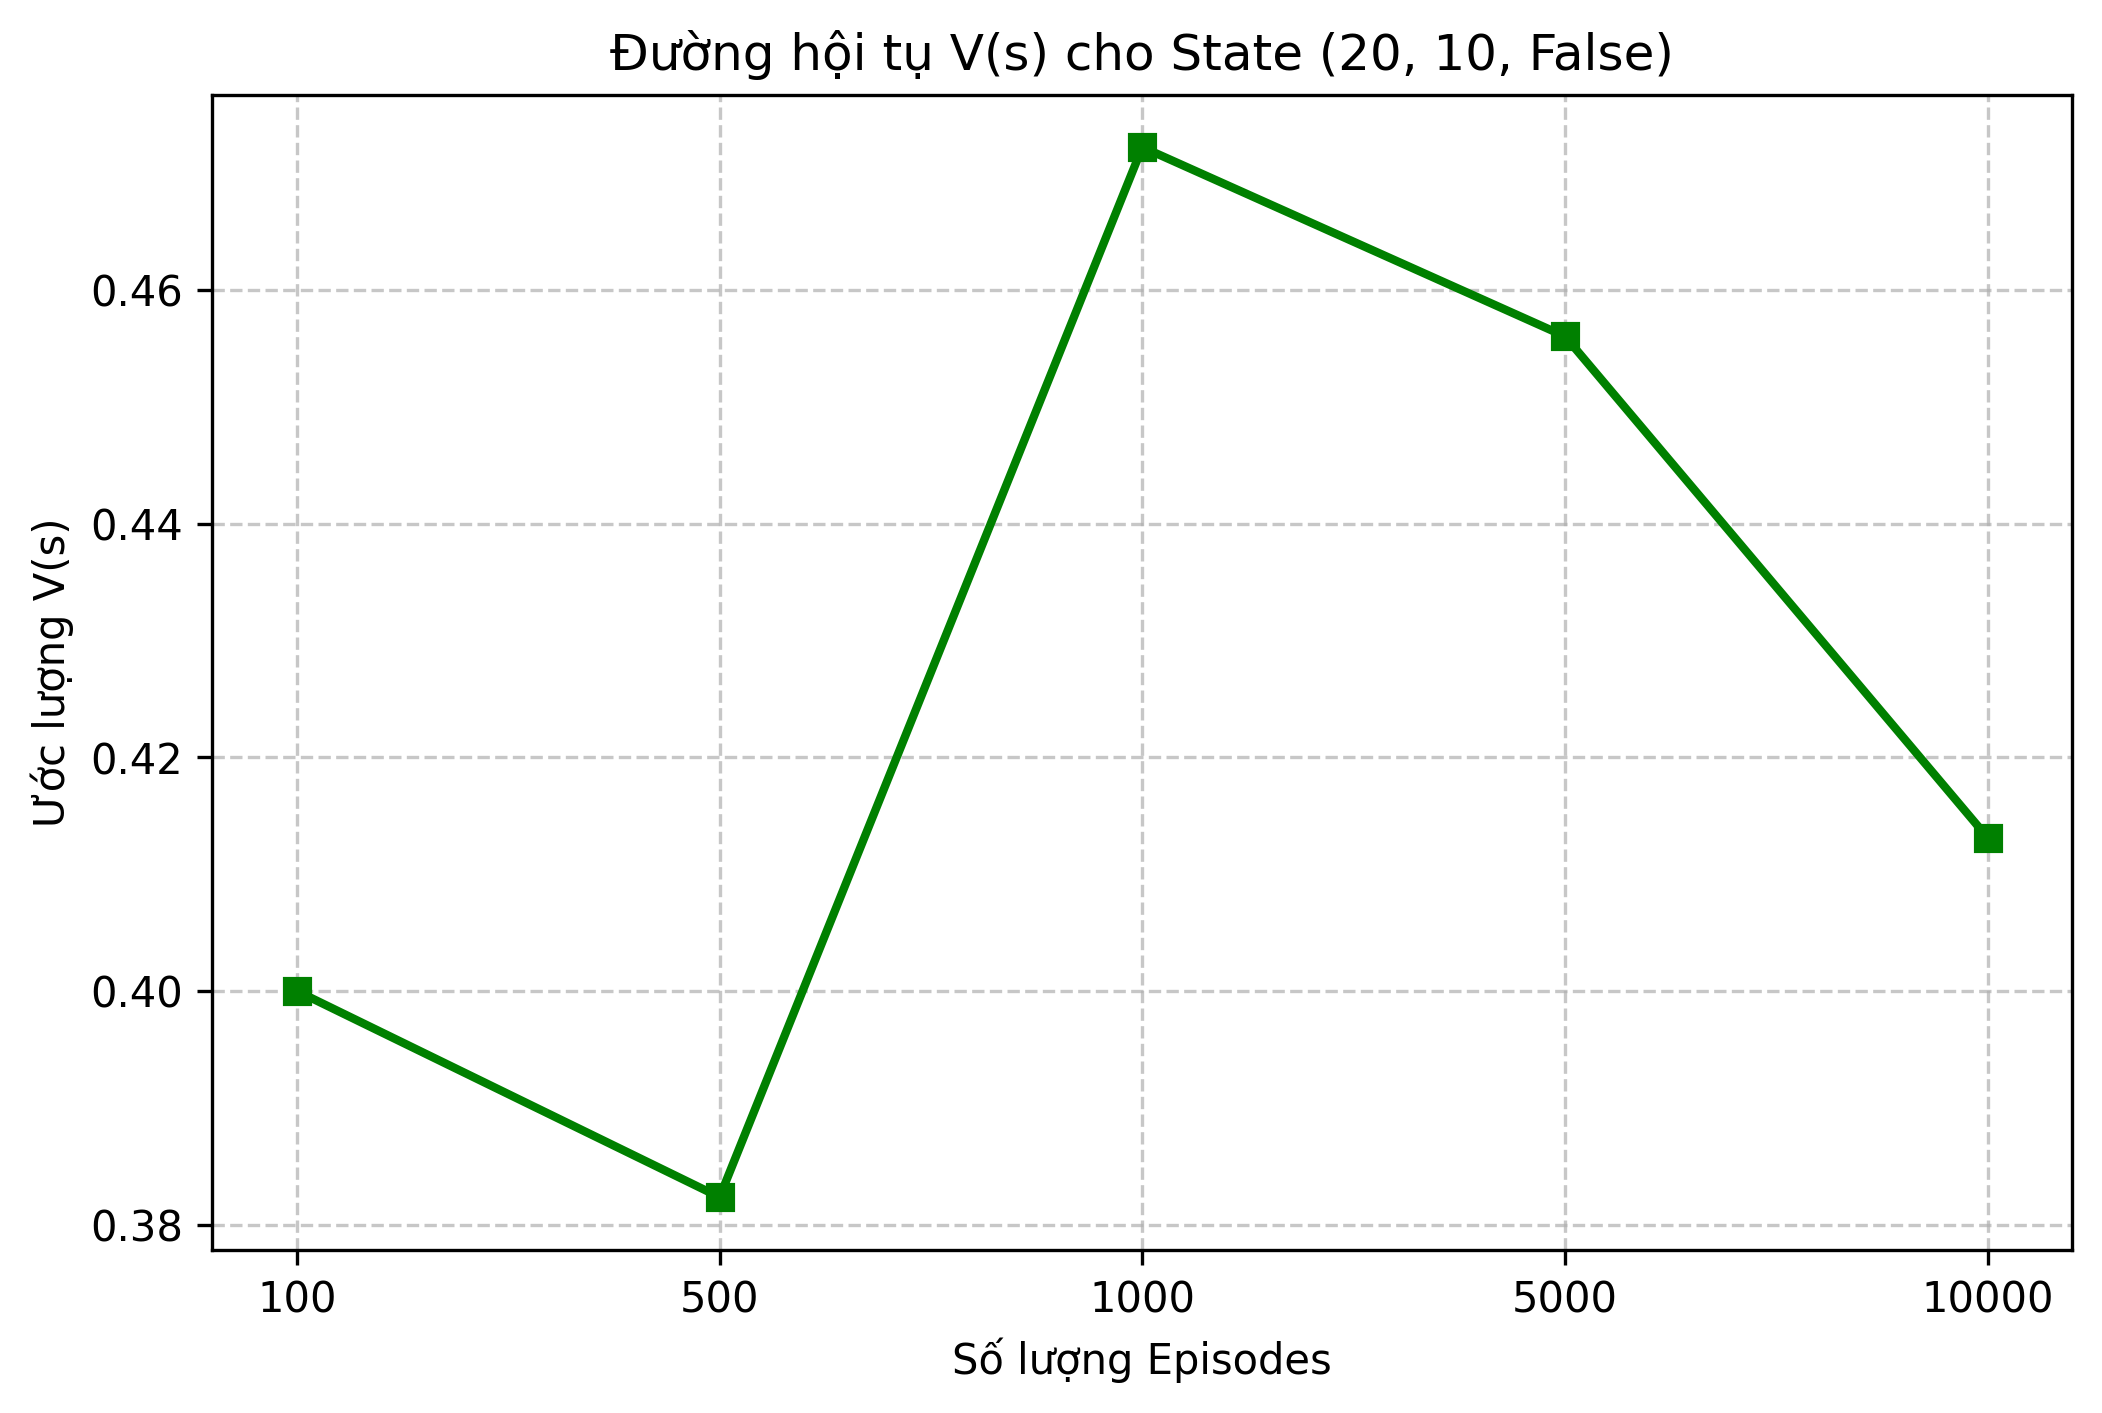

In [3]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai15.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 15: Theo dõi sự hội tụ của một state cụ thể"""
import os
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from mc_utils import generate_episode, compute_returns, stick_on_20_policy

def main():
    env = gym.make("Blackjack-v1")
    target_state = (20, 10, False)
    checkpoints = [100, 500, 1000, 5000, 10000]
    
    returns = defaultdict(list)
    estimates = []
    
    print(f"Theo dõi trạng thái mục tiêu {target_state}:")
    
    for ep_idx in range(1, max(checkpoints) + 1):
        ep = generate_episode(env, policy=stick_on_20_policy, seed=ep_idx)
        rewards = [step[2] for step in ep]
        g_list = compute_returns(rewards, gamma=1.0)
        
        for idx, step in enumerate(ep):
            state = step[0]
            returns[state].append(g_list[idx])
            
        if ep_idx in checkpoints:
            v_val = np.mean(returns[target_state]) if len(returns[target_state]) > 0 else 0.0
            estimates.append(v_val)
            print(f"  Episode {ep_idx:5d}: V(state) = {v_val:.4f} (Số lượt thăm: {len(returns[target_state])})")
            
    # Lưu và vẽ biểu đồ hội tụ
    fig_dir = os.path.join(".", "figures")
    os.makedirs(fig_dir, exist_ok=True)
    
    plt.figure(figsize=(8, 5))
    plt.plot([str(cp) for cp in checkpoints], estimates, marker='s', color='g', linewidth=2)
    plt.title(f"Đường hội tụ V(s) cho State {target_state}")
    plt.xlabel("Số lượng Episodes")
    plt.ylabel("Ước lượng V(s)")
    plt.grid(True, linestyle="--", alpha=0.7)
    
    output_path = os.path.join(fig_dir, "mc_convergence.png")
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"\\nĐã lưu biểu đồ hội tụ tại: {output_path}")
    plt.show()
    
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

from IPython.display import Image, display
display(Image(filename="figures/mc_convergence.png"))

## **Bài Tập Phần D: First - Visit Monte Carlo**

### **Bài 16. Phát hiện first visit**
Viết hàm xác định vị trí (chỉ số) lần đầu tiên xuất hiện của từng trạng thái trong một episode mà không dùng thư viện RL ngoài.   

**Mục đích:** Xây dựng logic để phân biệt First-Visit Monte Carlo và Every-Visit Monte Carlo. 

In [4]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai16.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 16: Phát hiện first visit trong episode"""
import gymnasium as gym
from mc_utils import generate_episode

def get_first_visit_indices(episode):
    """
    Trả về dict dạng {state: first_index}
    chứa vị trí xuất hiện ĐẦU TIÊN của mỗi state trong episode.
    """
    first_visits = {}
    for idx, step in enumerate(episode):
        state = step[0]
        if state not in first_visits:
            first_visits[state] = idx
    return first_visits

def main():
    env = gym.make("Blackjack-v1")
    # Sinh 1 episode mẫu
    ep = generate_episode(env, seed=42)
    
    print("Các bước trong episode (state, action, reward):")
    for idx, step in enumerate(ep):
        print(f"  Bước {idx}: State = {step[0]}")
        
    fv_map = get_first_visit_indices(ep)
    print("\\nKết quả vị trí First-Visit của từng State:")
    for st, f_idx in fv_map.items():
        print(f"  State {st} xuất hiện lần đầu ở bước {f_idx}")
        
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Các bước trong episode (state, action, reward):
  Bước 0: State = (15, 2, 0)

Kết quả vị trí First-Visit của từng State:
  State (15, 2, 0) xuất hiện lần đầu ở bước 0


### **Bài 17. First-Visit MC Prediction**
Đóng gói hàm first_visit_mc_prediction(env, policy, n_episodes, gamma=1.0) trả về tuple (V, returns_count).

**Mục đích:** Xây dựng thuật toán First-Visit MC để ước lượng hàm giá trị $V(s)$

In [8]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai17.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 17: First-Visit MC Prediction"""
import os
import gymnasium as gym
import numpy as np
from collections import defaultdict
from mc_utils import generate_episode, compute_returns, stick_on_20_policy

def first_visit_mc_prediction(env, policy, n_episodes, gamma=1.0):
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)
    
    for ep_idx in range(n_episodes):
        ep = generate_episode(env, policy=policy, seed=ep_idx)
        rewards = [step[2] for step in ep]
        g_list = compute_returns(rewards, gamma=gamma)
        
        visited_states = set()
        for idx, step in enumerate(ep):
            state = step[0]
            if state not in visited_states:
                visited_states.add(state)
                returns_sum[state] += g_list[idx]
                returns_count[state] += 1
                
    V = {state: returns_sum[state] / returns_count[state] for state in returns_sum}
    return V, returns_count

def main():
    env = gym.make("Blackjack-v1")
    
    # 1. Gọi hàm và nhận lại V cùng returns_count
    V, returns_count = first_visit_mc_prediction(env, stick_on_20_policy, n_episodes=500)
    
    print(f"Tổng số states: {len(V)}")
    print(f"{'State (Player, Dealer, Ace)':<28} | {'V(s)':<10} | {'returns_count':<15}")
    print("-" * 60)
    
    # 2. In mẫu 10 trạng thái đầu tiên để kiểm tra dữ liệu trong V và returns_count
    for state in list(V.keys())[:10]:
        v_val = V[state]
        count_val = returns_count[state]
        print(f"{str(state):<28} | {v_val:<10.4f} | {count_val:<15d}")

    # Ghi nhận/cập nhật lại hàm vào src/mc_utils.py
    utils_path = os.path.join("src", "mc_utils.py")
    if os.path.exists(utils_path):
        with open(utils_path, "a", encoding="utf-8") as f:
            f.write("\\n\\ndef first_visit_mc_prediction(env, policy, n_episodes, gamma=1.0):\\n    returns_sum = defaultdict(float)\\n    returns_count = defaultdict(int)\\n    for ep_idx in range(n_episodes):\\n        ep = generate_episode(env, policy=policy, seed=ep_idx)\\n        rewards = [step[2] for step in ep]\\n        g_list = compute_returns(rewards, gamma=gamma)\\n        visited_states = set()\\n        for idx, step in enumerate(ep):\\n            state = step[0]\\n            if state not in visited_states:\\n                visited_states.add(state)\\n                returns_sum[state] += g_list[idx]\\n                returns_count[state] += 1\\n    V = {state: returns_sum[state] / returns_count[state] for state in returns_sum}\\n    return V, returns_count\\n")
            
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Tổng số states: 206
State (Player, Dealer, Ace)  | V(s)       | returns_count  
------------------------------------------------------------
(11, 10, 0)                  | 0.0000     | 10             
(12, 10, 0)                  | -0.8824    | 17             
(13, 10, 0)                  | -0.4286    | 14             
(16, 10, 0)                  | -0.8095    | 21             
(20, 7, 0)                   | 1.0000     | 7              
(6, 10, 0)                   | -0.7500    | 4              
(14, 10, 0)                  | -0.7407    | 27             
(19, 10, 0)                  | -0.9375    | 32             
(7, 10, 0)                   | -0.4286    | 7              
(17, 10, 0)                  | -0.7333    | 30             


### **Bài 18. Chạy First-Visit MC**
Chạy first_visit_mc_prediction với số lượng episode lần lượt là 100, 1000, 10000, 50000 và in số lượng state đã được ước lượng.   

**Mục đích:** Khảo sát độ bao phủ không gian trạng thái của thuật toán khi tăng số lượng thử nghiệm.

In [6]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai18.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 18: Đánh giá số lượng state theo số episode"""
import gymnasium as gym
from mc_utils import first_visit_mc_prediction, stick_on_20_policy

def main():
    env = gym.make("Blackjack-v1")
    episodes_list = [100, 1000, 10000, 50000]
    
    print("Thống kê số lượng state đã được ước lượng:")
    for n_ep in episodes_list:
        V, _ = first_visit_mc_prediction(env, stick_on_20_policy, n_episodes=n_ep)
        print(f"  Số episodes = {n_ep:5d} -> Số state đã ước lượng được: {len(V):3d}")
        
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Thống kê số lượng state đã được ước lượng:
  Số episodes =   100 -> Số state đã ước lượng được:  91
  Số episodes =  1000 -> Số state đã ước lượng được: 234
  Số episodes = 10000 -> Số state đã ước lượng được: 280
  Số episodes = 50000 -> Số state đã ước lượng được: 280


### **Bài 19. Visualize value**
Trích xuất các state có usable_ace = False (với player_sum từ 12 đến 21 và dealer_card từ 1 đến 10) sau 50,000 episode và vẽ Heatmap biểu diễn hàm giá trị $V(s)$. 

**Mục đích:** Trực quan hóa giá trị trạng thái $V(s)$ của stick_on_20_policy dưới dạng biểu đồ nhiệt

Đã lưu Heatmap tại: .\figures\policy_performance.png
Figure(1000x700)


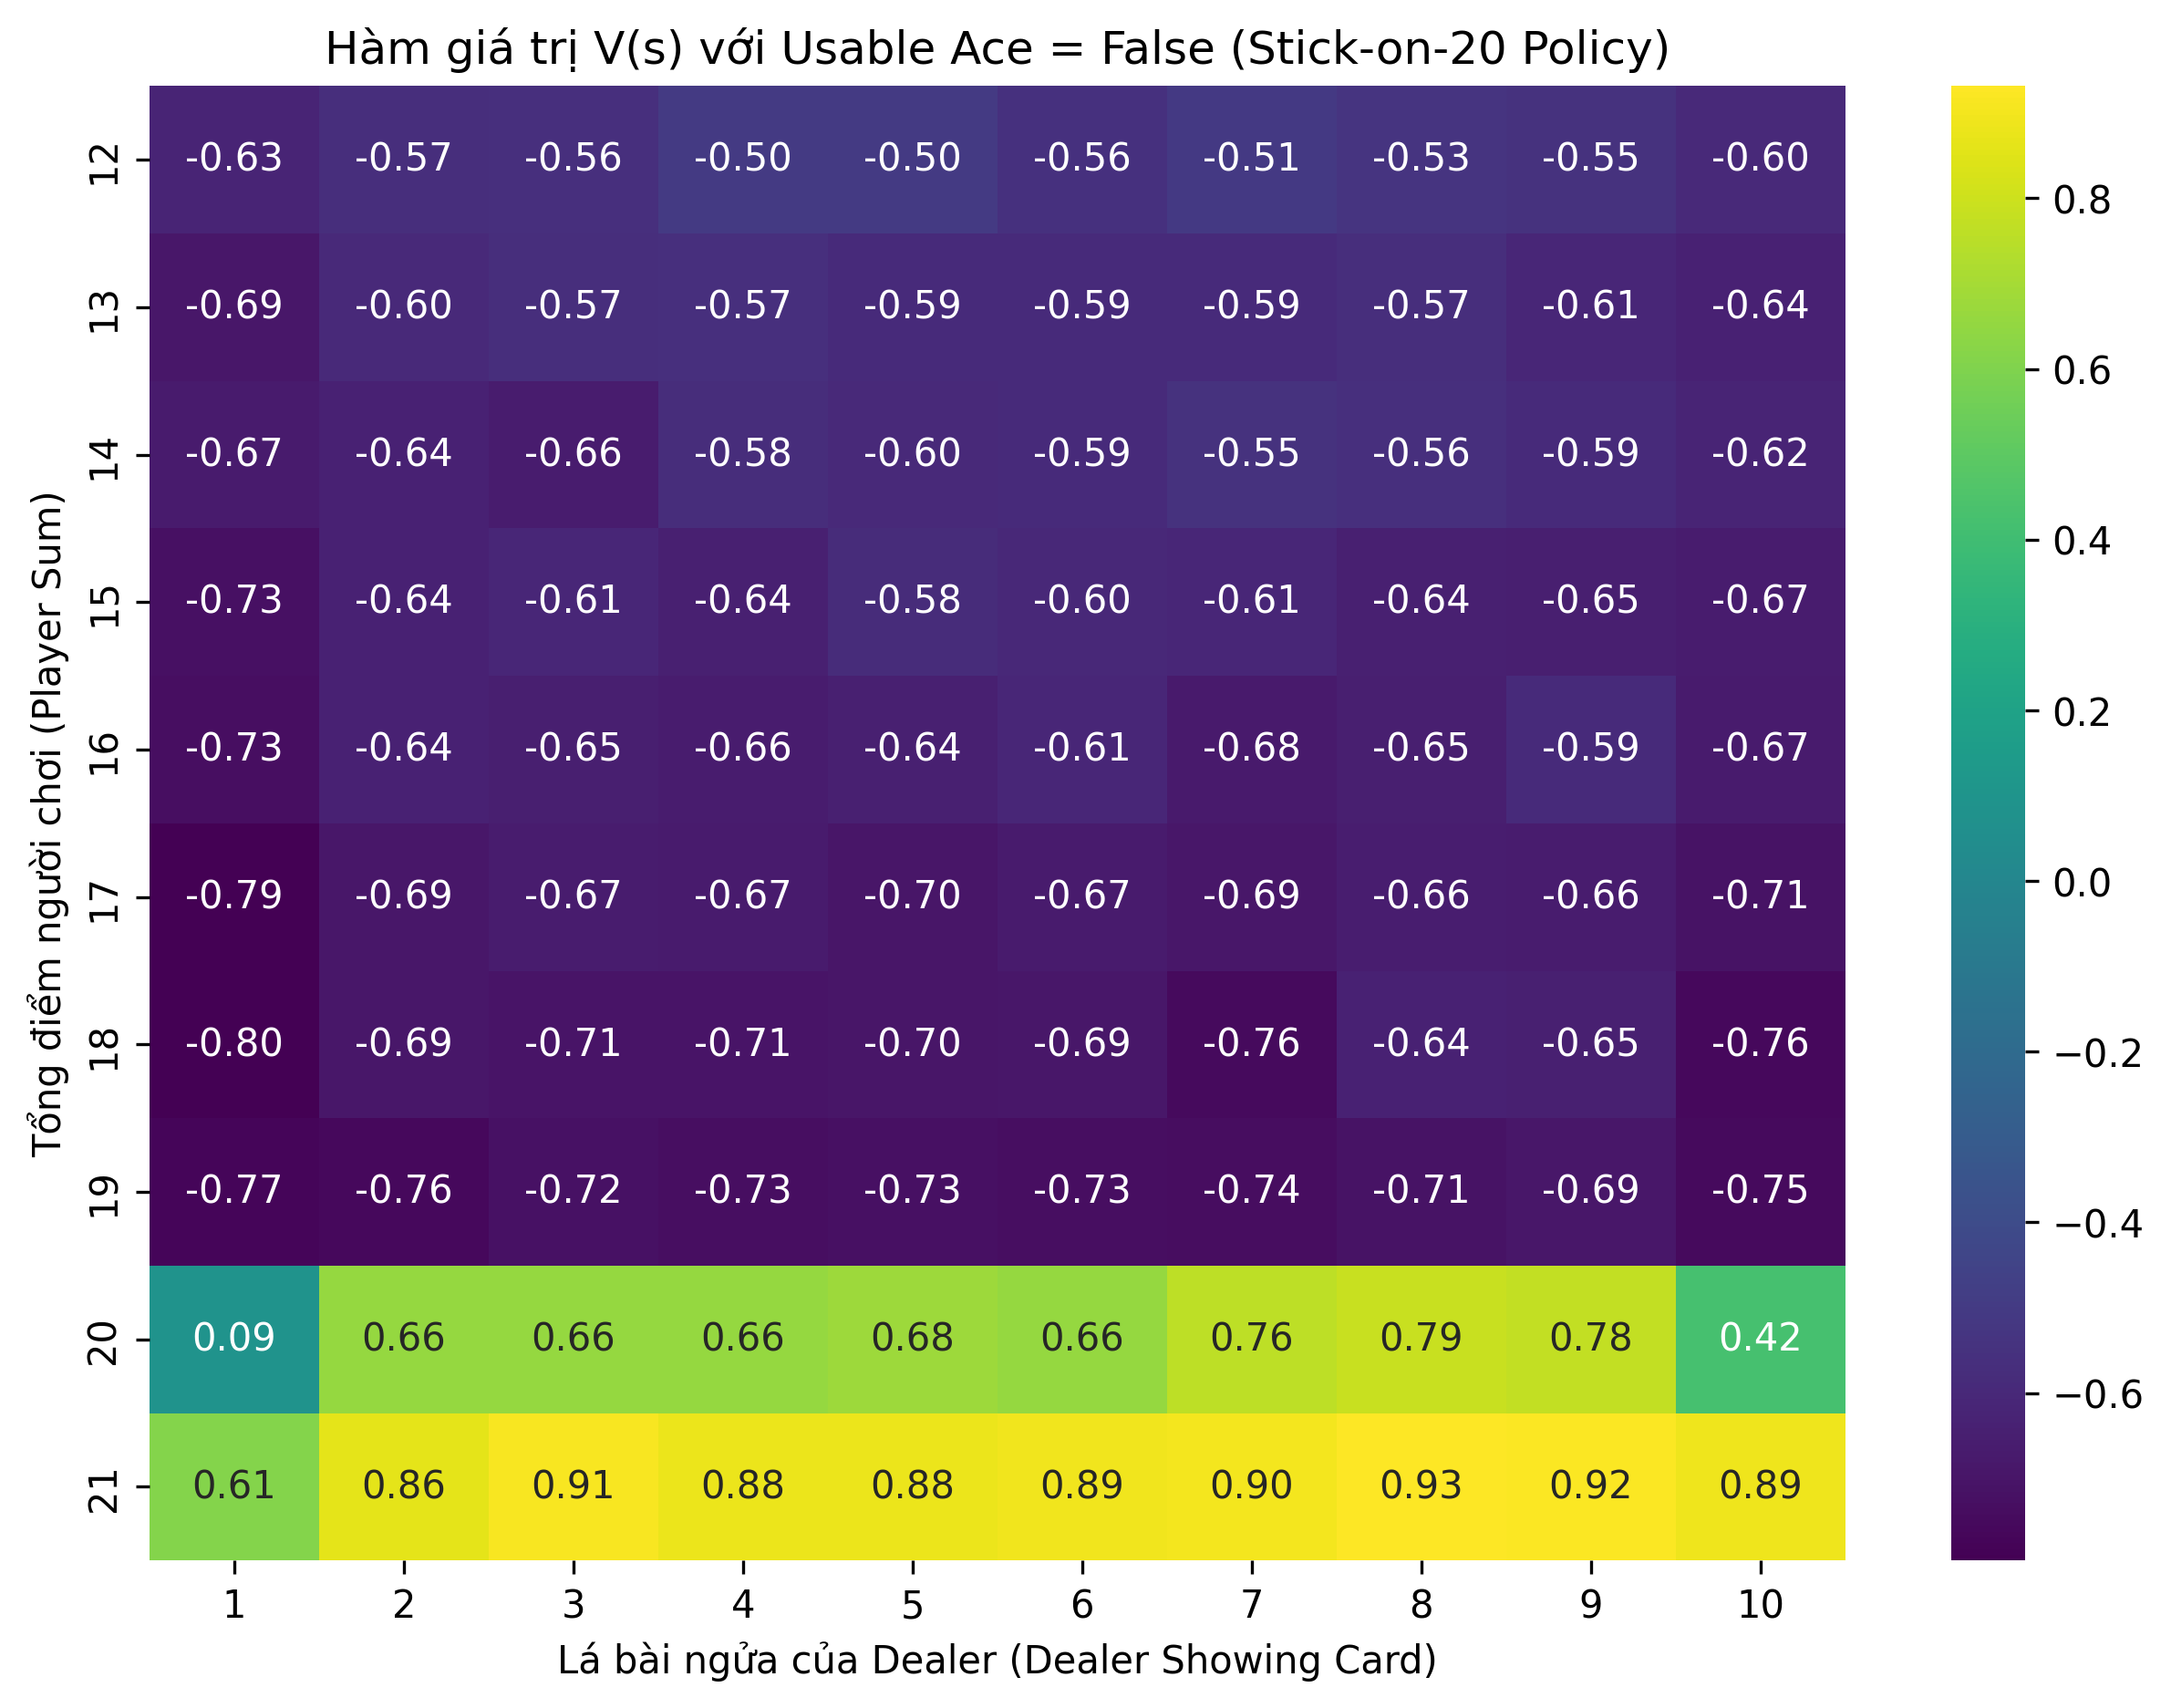

In [9]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai19.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 19: Visualize value"""
import os
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mc_utils import first_visit_mc_prediction, stick_on_20_policy

def main():
    env = gym.make("Blackjack-v1")
    V, _ = first_visit_mc_prediction(env, stick_on_20_policy, n_episodes=50000)
    
    # Tạo ma trận giá trị cho Usable Ace = False
    # Player sum: 12 -> 21 (10 dòng), Dealer showing card: 1 -> 10 (10 cột)
    value_grid = np.zeros((10, 10))
    
    for p_sum in range(12, 22):
        for d_card in range(1, 11):
            state = (p_sum, d_card, False)
            value_grid[p_sum - 12, d_card - 1] = V.get(state, 0.0)
            
    # Vẽ Heatmap
    fig_dir = os.path.join(".", "figures")
    os.makedirs(fig_dir, exist_ok=True)
    
    plt.figure(figsize=(10, 7))
    sns.heatmap(value_grid, xticklabels=range(1, 11), yticklabels=range(12, 22), 
                cmap="viridis", annot=True, fmt=".2f")
    plt.title("Hàm giá trị V(s) với Usable Ace = False (Stick-on-20 Policy)")
    plt.xlabel("Lá bài ngửa của Dealer (Dealer Showing Card)")
    plt.ylabel("Tổng điểm người chơi (Player Sum)")
    
    output_path = os.path.join(fig_dir, "policy_performance.png")
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Đã lưu Heatmap tại: {output_path}")
    plt.show()
    
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

from IPython.display import Image, display
display(Image(filename="figures/policy_performance.png"))

## **Bài Tập Phần E: Every - Visit Monte Carlo**

### **Bài 20. Every-Visit MC Prediction**
Định nghĩa hàm every_visit_mc_prediction(env, policy, n_episodes, gamma=1.0) tính toán trung bình return $G_t$ cho mỗi lần một trạng thái xuất hiện trong episode. 

**Mục đích:** Xây dựng biến thể Every-Visit Monte Carlo và phân biệt sự khác nhau với First-Visit Monte Carlo.

In [10]:
import os

BASE = "."
file_path = os.path.join(BASE, "src", "bai20.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 20: Every-Visit MC Prediction"""
import os
import gymnasium as gym
import numpy as np
from collections import defaultdict
from mc_utils import generate_episode, compute_returns, first_visit_mc_prediction, stick_on_20_policy

def every_visit_mc_prediction(env, policy, n_episodes, gamma=1.0):
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)
    
    for ep_idx in range(n_episodes):
        ep = generate_episode(env, policy=policy, seed=ep_idx)
        rewards = [step[2] for step in ep]
        g_list = compute_returns(rewards, gamma=gamma)
        
        for idx, step in enumerate(ep):
            state = step[0]
            returns_sum[state] += g_list[idx]
            returns_count[state] += 1
                
    V = {state: returns_sum[state] / returns_count[state] for state in returns_sum}
    return V, returns_count

def main():
    env = gym.make("Blackjack-v1")
    n_ep = 5000
    
    V_fv, count_fv = first_visit_mc_prediction(env, stick_on_20_policy, n_episodes=n_ep)
    V_ev, count_ev = every_visit_mc_prediction(env, stick_on_20_policy, n_episodes=n_ep)
    
    print(f"So sánh sau {n_ep} episodes:")
    sample_state = (14, 8, False)
    print(f"  State {sample_state}:")
    print(f"    - First-Visit : V(s) = {V_fv.get(sample_state, 0):.4f} | Số lượt tính = {count_fv.get(sample_state, 0)}")
    print(f"    - Every-Visit : V(s) = {V_ev.get(sample_state, 0):.4f} | Số lượt tính = {count_ev.get(sample_state, 0)}")
    
    # Ghi nhận hàm này vào mc_utils.py
    utils_path = os.path.join("src", "mc_utils.py")
    if os.path.exists(utils_path):
        with open(utils_path, "a", encoding="utf-8") as f:
            f.write("\\n\\ndef every_visit_mc_prediction(env, policy, n_episodes, gamma=1.0):\\n    returns_sum = defaultdict(float)\\n    returns_count = defaultdict(int)\\n    for ep_idx in range(n_episodes):\\n        ep = generate_episode(env, policy=policy, seed=ep_idx)\\n        rewards = [step[2] for step in ep]\\n        g_list = compute_returns(rewards, gamma=gamma)\\n        for idx, step in enumerate(ep):\\n            state = step[0]\\n            returns_sum[state] += g_list[idx]\\n            returns_count[state] += 1\\n    V = {state: returns_sum[state] / returns_count[state] for state in returns_sum}\\n    return V, returns_count\\n")
            
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

So sánh sau 5000 episodes:
  State (14, 8, False):
    - First-Visit : V(s) = -0.5385 | Số lượt tính = 39
    - Every-Visit : V(s) = -0.5385 | Số lượt tính = 39


### **Bài 21. So sánh First-Visit và Every-Visit**
Chạy cả hai với cùng policy, gamma, n_episodes và seed. So sánh V(s) tại ít nhất 10 state.   

**Mục đích:** Đánh giá điểm tương đồng và khác biệt về mặt định lượng giữa First-Visit Monte Carlo và Every-Visit Monte Carlo

In [12]:
import os

file_path = os.path.join(".", "src", "bai21.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 21: So sánh First-Visit và Every-Visit"""
import gymnasium as gym
from mc_utils import first_visit_mc_prediction, every_visit_mc_prediction, stick_on_20_policy

def main():
    env = gym.make("Blackjack-v1")
    n_episodes = 10000
    gamma = 1.0
    
    V_first, _ = first_visit_mc_prediction(env, stick_on_20_policy, n_episodes=n_episodes, gamma=gamma)
    V_every, _ = every_visit_mc_prediction(env, stick_on_20_policy, n_episodes=n_episodes, gamma=gamma)
    
    common_states = list(set(V_first.keys()).intersection(set(V_every.keys())))[:10]
    
    print(f"{'State':<25} | {'V_first(s)':<12} | {'V_every(s)':<12}")
    print("-" * 55)
    for st in common_states:
        print(f"{str(st):<25} | {V_first[st]:<12.4f} | {V_every[st]:<12.4f}")
        
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

State                     | V_first(s)   | V_every(s)  
-------------------------------------------------------
(15, 5, 0)                | -0.5050      | -0.5050     
(12, 10, 0)               | -0.6299      | -0.6299     
(18, 10, 0)               | -0.7235      | -0.7235     
(8, 6, 0)                 | -0.2083      | -0.2083     
(21, 6, 0)                | 0.8615       | 0.8615      
(7, 9, 0)                 | -0.1765      | -0.1765     
(10, 4, 0)                | -0.2778      | -0.2778     
(16, 5, 0)                | -0.6083      | -0.6083     
(17, 10, 1)               | -0.3208      | -0.3208     
(20, 6, 0)                | 0.6667       | 0.6667      


### **Bài 22. Sai khác giữa hai phương pháp**
Tính abs(V_first[state] - V_every[state]) và mean absolute difference trên các state chung.   

**Mục đích:** Đo lường mức độ chênh lệch trung bình giữa hai phương pháp dự đoán Monte Carlo.

In [13]:
import os

file_path = os.path.join(".", "src", "bai22.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 22: Sai khác giữa hai phương pháp"""
import gymnasium as gym
import numpy as np
from mc_utils import first_visit_mc_prediction, every_visit_mc_prediction, stick_on_20_policy

def main():
    env = gym.make("Blackjack-v1")
    n_episodes = 10000
    
    V_first, _ = first_visit_mc_prediction(env, stick_on_20_policy, n_episodes=n_episodes)
    V_every, _ = every_visit_mc_prediction(env, stick_on_20_policy, n_episodes=n_episodes)
    
    common_states = set(V_first.keys()).intersection(set(V_every.keys()))
    diffs = [abs(V_first[st] - V_every[st]) for st in common_states]
    
    mean_abs_diff = np.mean(diffs)
    print(f"Mean absolute difference trên {len(common_states)} state chung: {mean_abs_diff:.6f}")
    
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Mean absolute difference trên 280 state chung: 0.000000


### **Bài 23. Biểu đồ hội tụChọn 3 state**
Vẽ estimate V(s) của First-Visit MC và Every-Visit MC theo số episode. 

**Mục đích:** Trực quan hóa tiến trình hội tụ và so sánh trực tiếp đường cong học của hai thuật toán.

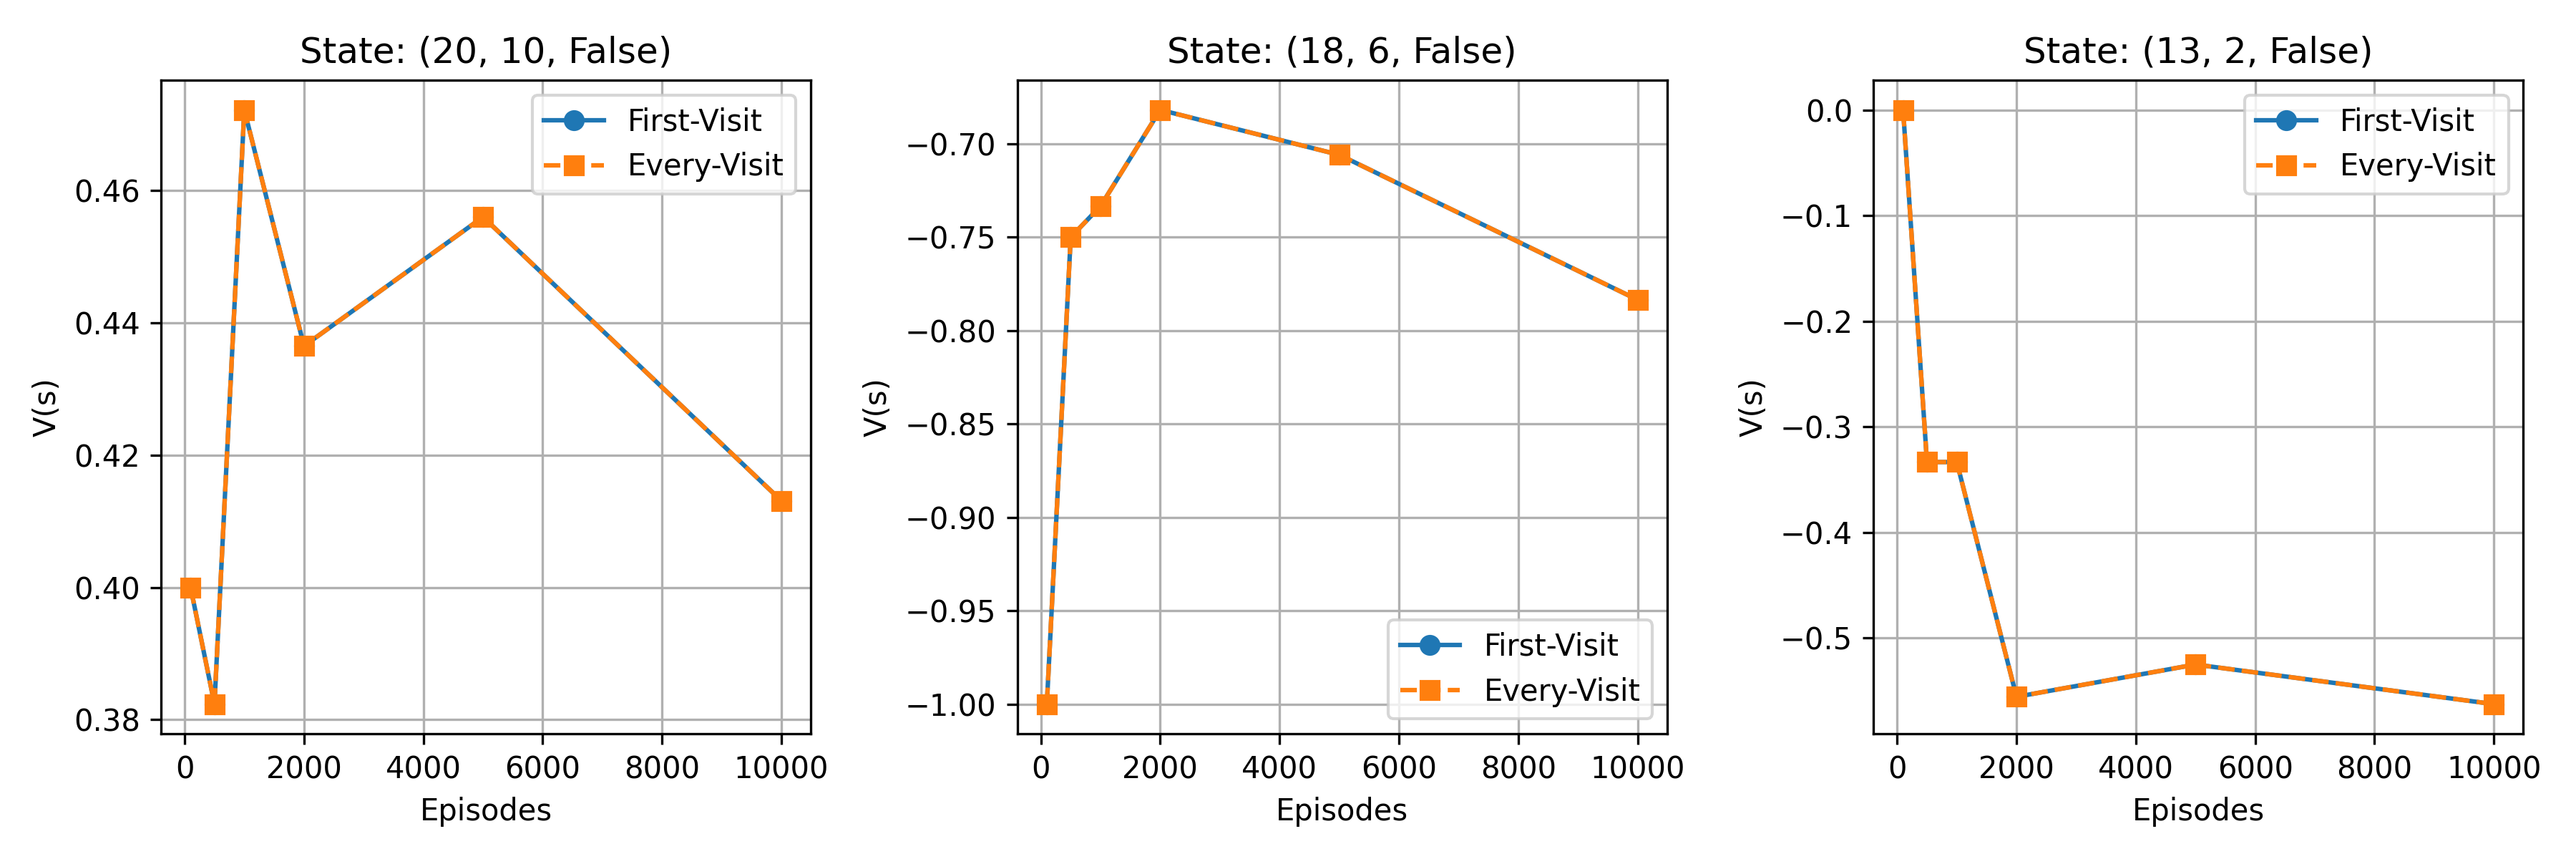

In [14]:
import os

file_path = os.path.join(".", "src", "bai23.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 23: Biểu đồ hội tụ"""
import os
import gymnasium as gym
import matplotlib.pyplot as plt
from collections import defaultdict
from mc_utils import generate_episode, compute_returns, stick_on_20_policy

def main():
    env = gym.make("Blackjack-v1")
    target_states = [(20, 10, False), (18, 6, False), (13, 2, False)]
    checkpoints = [100, 500, 1000, 2000, 5000, 10000]
    
    first_history = {st: [] for st in target_states}
    every_history = {st: [] for st in target_states}
    
    first_sum, first_count = defaultdict(float), defaultdict(int)
    every_sum, every_count = defaultdict(float), defaultdict(int)
    
    for ep_idx in range(1, max(checkpoints) + 1):
        ep = generate_episode(env, policy=stick_on_20_policy, seed=ep_idx)
        rewards = [step[2] for step in ep]
        g_list = compute_returns(rewards, gamma=1.0)
        
        visited_first = set()
        for idx, step in enumerate(ep):
            st = step[0]
            every_sum[st] += g_list[idx]
            every_count[st] += 1
            
            if st not in visited_first:
                visited_first.add(st)
                first_sum[st] += g_list[idx]
                first_count[st] += 1
                
        if ep_idx in checkpoints:
            for st in target_states:
                v_f = first_sum[st] / first_count[st] if first_count[st] > 0 else 0.0
                v_e = every_sum[st] / every_count[st] if every_count[st] > 0 else 0.0
                first_history[st].append(v_f)
                every_history[st].append(v_e)
                
    fig_dir = os.path.join("Lab03", "figures")
    os.makedirs(fig_dir, exist_ok=True)
    
    plt.figure(figsize=(12, 4))
    for i, st in enumerate(target_states):
        plt.subplot(1, 3, i + 1)
        plt.plot(checkpoints, first_history[st], label="First-Visit", marker='o')
        plt.plot(checkpoints, every_history[st], label="Every-Visit", marker='s', linestyle='--')
        plt.title(f"State: {st}")
        plt.xlabel("Episodes")
        plt.ylabel("V(s)")
        plt.legend()
        plt.grid(True)
        
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, "first_vs_every_visit.png"), dpi=300)
    plt.close()
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

from IPython.display import Image, display
display(Image(filename="Lab03/figures/first_vs_every_visit.png"))

## **Bài Tập Phần F: Action - Value Function Q(s, a)**

### **Bài 24. Lưu state-action-return**
Thay vì state -> return, lưu (state, action) -> return bằng defaultdict(list).   

**Mục đích:** Xây dựng cấu trúc lưu trữ dữ liệu để chuyển từ đánh giá giá trị trạng thái $V(s)$ sang giá trị hành động $Q(s,a)$

In [15]:
import os

file_path = os.path.join(".", "src", "bai24.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 24: Lưu state-action-return"""
import gymnasium as gym
from collections import defaultdict
from mc_utils import generate_episode, compute_returns, stick_on_20_policy

def main():
    env = gym.make("Blackjack-v1")
    returns_sa = defaultdict(list)
    
    for ep_idx in range(100):
        ep = generate_episode(env, policy=stick_on_20_policy, seed=ep_idx)
        rewards = [step[2] for step in ep]
        g_list = compute_returns(rewards, gamma=1.0)
        
        for idx, step in enumerate(ep):
            st, action, _ = step
            returns_sa[(st, action)].append(g_list[idx])
            
    print(f"Số cặp (state, action) thu thập được: {len(returns_sa)}")
    sample_sa = list(returns_sa.keys())[0]
    print(f"{sample_sa}: {returns_sa[sample_sa][:5]}")
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Số cặp (state, action) thu thập được: 91
((11, 10, 0), 1): [-1.0]


### **Bài 25. Ước lượng Q(s,a)**
Viết hàm mc_action_value_prediction(env, policy, n_episodes, gamma=1.0) trả về Q, trong đó Q[state][action].

**Mục đích:** Thực hiện thuật toán ước lượng hàm giá trị hành động $Q(s,a)$ sử dụng phương pháp Monte Carlo.

In [18]:
import os

file_path = os.path.join(".", "src", "bai25.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 25: Ước lượng Q(s,a)"""
import os
import gymnasium as gym
import numpy as np
from collections import defaultdict
from mc_utils import generate_episode, compute_returns, stick_on_20_policy

def mc_action_value_prediction(env, policy, n_episodes, gamma=1.0):
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)
    
    for ep_idx in range(n_episodes):
        ep = generate_episode(env, policy=policy, seed=ep_idx)
        rewards = [step[2] for step in ep]
        g_list = compute_returns(rewards, gamma=gamma)
        
        visited_sa = set()
        for idx, step in enumerate(ep):
            st, action, _ = step
            sa = (st, action)
            if sa not in visited_sa:
                visited_sa.add(sa)
                returns_sum[sa] += g_list[idx]
                returns_count[sa] += 1
                
    Q = defaultdict(lambda: np.zeros(env.action_space.n))
    for (st, action), total_r in returns_sum.items():
        Q[st][action] = total_r / returns_count[(st, action)]
        
    return Q

def main():
    env = gym.make("Blackjack-v1")
    n_episodes = 10000
    Q = mc_action_value_prediction(env, stick_on_20_policy, n_episodes=n_episodes)
    
    # In giá trị Q[state][action] cụ thể cho một số state ví dụ
    sample_states = [(20, 10, False), (18, 6, False), (13, 2, False)]
    
    print(f"Tổng số state thu thập được Q: {len(Q)}\\n")
    print(f"{'State':<20} | {'Q(s, Action=0/Stick)':<22} | {'Q(s, Action=1/Hit)':<20}")
    print("-" * 68)
    
    for st in sample_states:
        q_stick = Q[st][0]  # Q[state][0]
        q_hit = Q[st][1]    # Q[state][1]
        print(f"{str(st):<20} | {q_stick:<22.4f} | {q_hit:<20.4f}")
    
    # Cập nhật hàm vào mc_utils.py
    utils_path = os.path.join("src", "mc_utils.py")
    if os.path.exists(utils_path):
        with open(utils_path, "a", encoding="utf-8") as f:
            f.write("\\n\\ndef mc_action_value_prediction(env, policy, n_episodes, gamma=1.0):\\n    from collections import defaultdict\\n    import numpy as np\\n    returns_sum = defaultdict(float)\\n    returns_count = defaultdict(int)\\n    for ep_idx in range(n_episodes):\\n        ep = generate_episode(env, policy=policy, seed=ep_idx)\\n        rewards = [step[2] for step in ep]\\n        g_list = compute_returns(rewards, gamma=gamma)\\n        visited_sa = set()\\n        for idx, step in enumerate(ep):\\n            st, action, _ = step\\n            sa = (st, action)\\n            if sa not in visited_sa:\\n                visited_sa.add(sa)\\n                returns_sum[sa] += g_list[idx]\\n                returns_count[sa] += 1\\n    Q = defaultdict(lambda: np.zeros(env.action_space.n))\\n    for (st, action), total_r in returns_sum.items():\\n        Q[st][action] = total_r / returns_count[(st, action)]\\n    return Q\\n")
            
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Tổng số state thu thập được Q: 280

State                | Q(s, Action=0/Stick)   | Q(s, Action=1/Hit)  
--------------------------------------------------------------------
(20, 10, False)      | 0.4131                 | 0.0000              
(18, 6, False)       | 0.0000                 | -0.7835             
(13, 2, False)       | 0.0000                 | -0.5625             


### **Bài 26. Greedy action từ Q**
Viết hàm greedy_action(Q, state, n_actions) sử dụng np.argmax(...).

**Mục đích:** Xây dựng cơ chế lựa chọn hành động tối ưu dựa trên bảng giá trị $Q(s,a)$

In [19]:
import os

file_path = os.path.join(".", "src", "bai26.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 26: Greedy action từ Q"""
import os
import numpy as np
from collections import defaultdict

def greedy_action(Q, state, n_actions):
    if state not in Q:
        return 0
    return int(np.argmax(Q[state]))

def main():
    Q = defaultdict(lambda: np.zeros(2))
    Q[(20, 10, False)] = np.array([0.8, 0.2])
    
    act = greedy_action(Q, (20, 10, False), 2)
    print(f"Greedy action được chọn: {act}")
    
    utils_path = os.path.join("src", "mc_utils.py")
    if os.path.exists(utils_path):
        with open(utils_path, "a", encoding="utf-8") as f:
            f.write("\\n\\ndef greedy_action(Q, state, n_actions):\\n    import numpy as np\\n    if state not in Q:\\n        return 0\\n    return int(np.argmax(Q[state]))\\n")

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Greedy action được chọn: 0


## **Bài Tập Phần G: Epsilon - Greedy và Exploration**

### **Bài 27. Epsilon-greedy policy**
Viết hàm epsilon_greedy_action(Q, state, n_actions, epsilon, rng).

**Mục đích:** Cài đặt $\epsilon$-greedy để cân bằng giữa Exploration và Exploitation.

In [20]:
import os

file_path = os.path.join(".", "src", "bai27.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 27: Epsilon-greedy policy"""
import os
import numpy as np
from collections import defaultdict

def epsilon_greedy_action(Q, state, n_actions, epsilon, rng):
    if rng.random() < epsilon:
        return rng.integers(0, n_actions)
    else:
        if state not in Q:
            return rng.integers(0, n_actions)
        return int(np.argmax(Q[state]))

def main():
    rng = np.random.default_rng(42)
    Q = defaultdict(lambda: np.zeros(2))
    Q[(15, 10, False)] = np.array([0.1, 0.9])
    
    act = epsilon_greedy_action(Q, (15, 10, False), 2, 0.1, rng)
    print(f"Action được chọn từ epsilon-greedy: {act}")
    
    utils_path = os.path.join("src", "mc_utils.py")
    if os.path.exists(utils_path):
        with open(utils_path, "a", encoding="utf-8") as f:
            f.write("\\n\\ndef epsilon_greedy_action(Q, state, n_actions, epsilon, rng):\\n    import numpy as np\\n    if rng.random() < epsilon:\\n        return rng.integers(0, n_actions)\\n    else:\\n        if state not in Q:\\n            return rng.integers(0, n_actions)\\n        return int(np.argmax(Q[state]))\\n")

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Action được chọn từ epsilon-greedy: 1


### **Bài 28. Kiểm tra epsilon-greedy**
Thử nghiệm với Q_values = [1.0, 5.0]. Sinh 10,000 action với epsilon = 0.1, đếm tần suất chọn action và nhận xét.

**Mục đích:** Tự động hóa kiểm định tính đúng đắn của phân phối xác suất trong chiến lược $\epsilon$-greedy.

In [21]:
import os

file_path = os.path.join(".", "src", "bai28.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 28: Kiểm tra epsilon-greedy"""
import numpy as np
from collections import defaultdict
from mc_utils import epsilon_greedy_action

def main():
    rng = np.random.default_rng(42)
    Q = defaultdict(lambda: np.zeros(2))
    state = "test_state"
    Q[state] = np.array([1.0, 5.0])
    
    n_samples = 10000
    epsilon = 0.1
    actions = [epsilon_greedy_action(Q, state, 2, epsilon, rng) for _ in range(n_samples)]
    
    count_0 = actions.count(0)
    count_1 = actions.count(1)
    
    print(f"Tần suất chọn Action 0 (Non-greedy): {count_0} ({count_0/n_samples*100:.2f}%)")
    print(f"Tần suất chọn Action 1 (Greedy)    : {count_1} ({count_1/n_samples*100:.2f}%)")
    print("Nhận xét: Tần suất phù hợp lý thuyết (Action 0 ~ 5%, Action 1 ~ 95%).")

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Tần suất chọn Action 0 (Non-greedy): 526 (5.26%)
Tần suất chọn Action 1 (Greedy)    : 9474 (94.74%)
Nhận xét: Tần suất phù hợp lý thuyết (Action 0 ~ 5%, Action 1 ~ 95%).


### **Bài 29. So sánh epsilon**
Thử các giá trị $\epsilon \in [0.01, 0.05, 0.10, 0.20, 0.50]$ và vẽ tần suất chọn greedy action. 

**Mục đích:** Phân tích ảnh hưởng của tham số $\epsilon$ tới mức độ ưu tiên khai thác hành động tối ưu.   

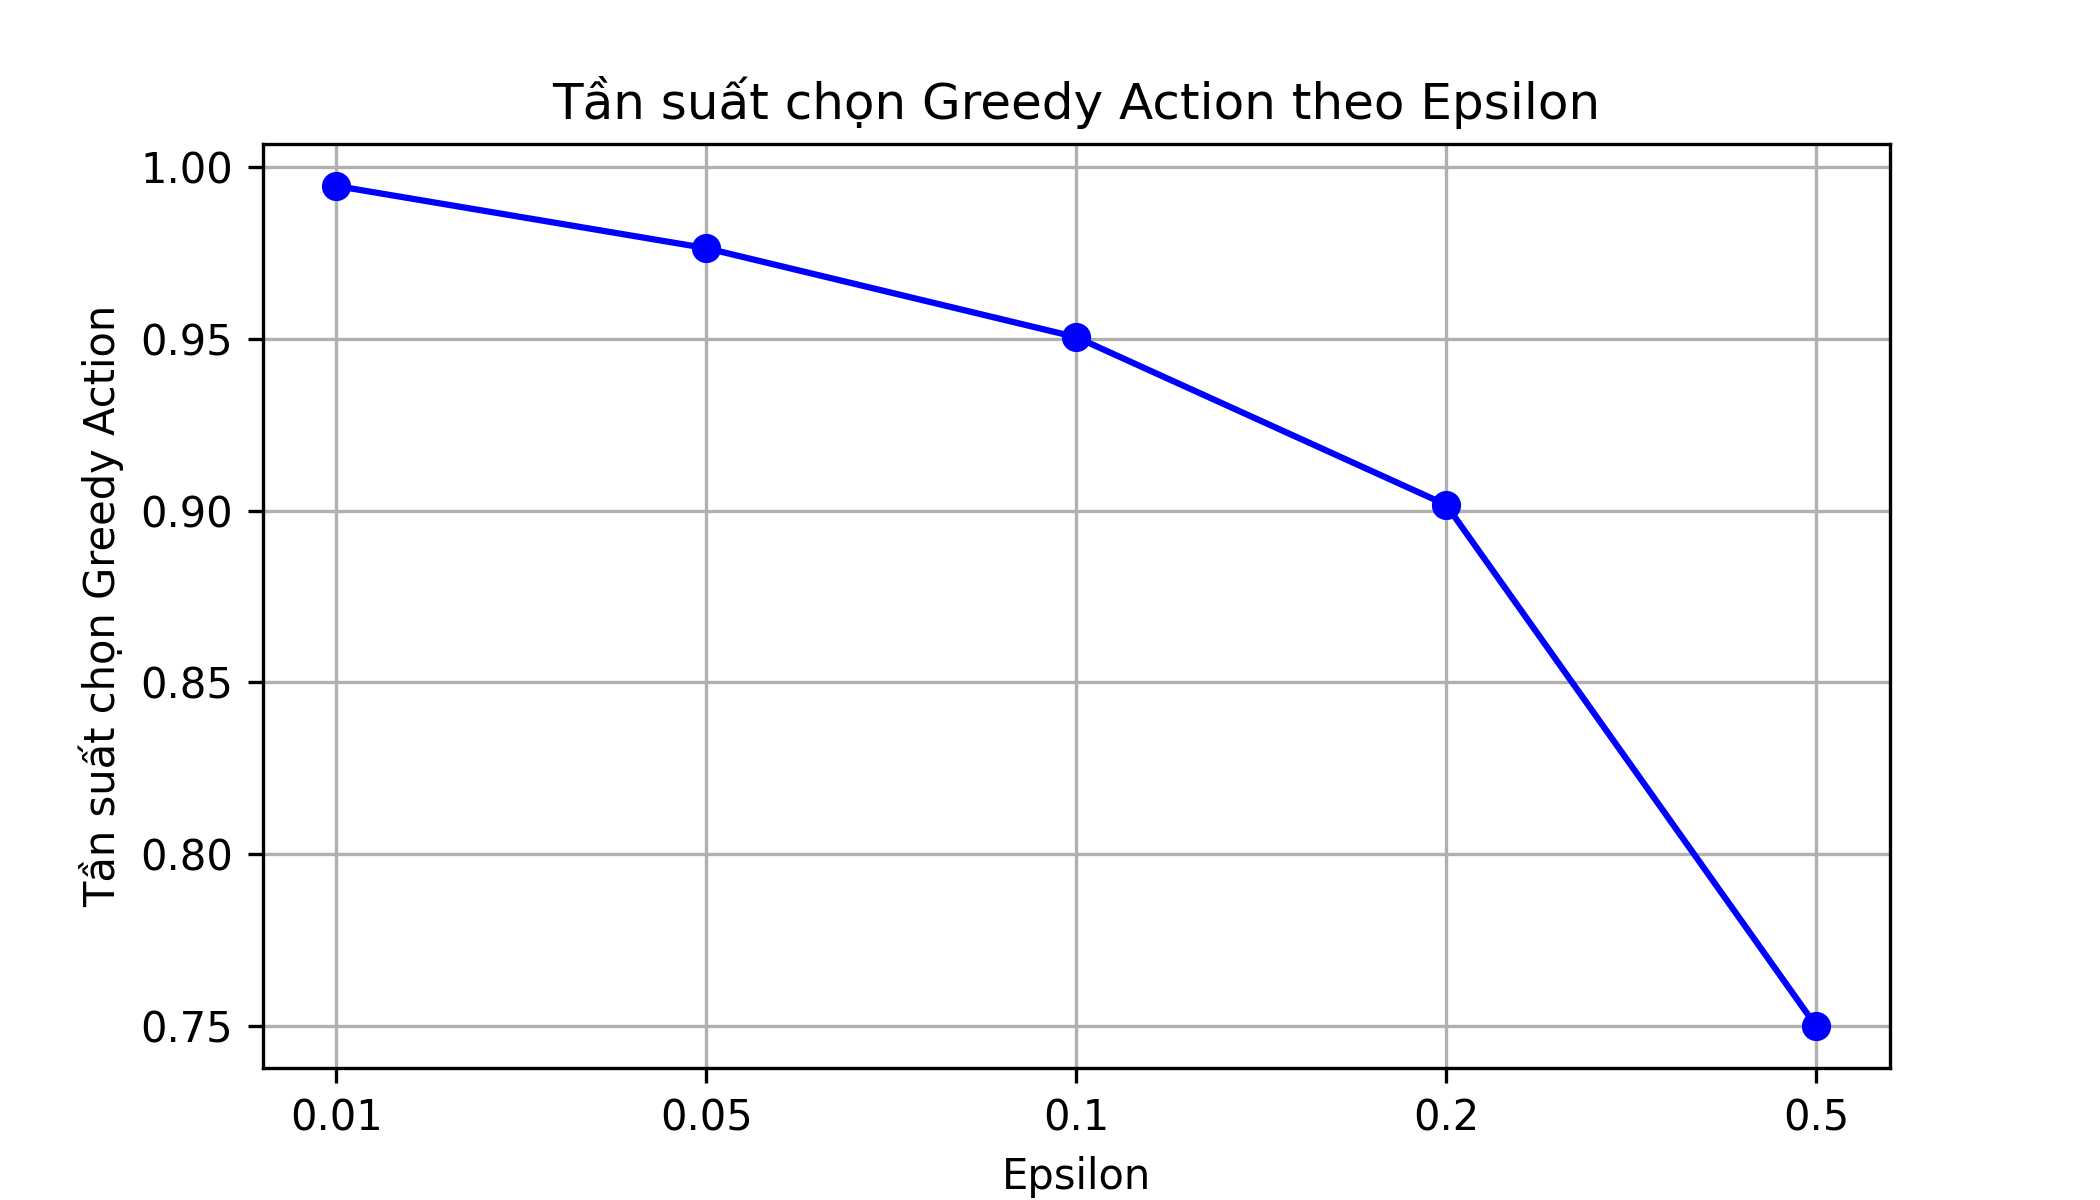

In [22]:
import os

file_path = os.path.join(".", "src", "bai29.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 29: So sánh epsilon"""
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from mc_utils import epsilon_greedy_action

def main():
    rng = np.random.default_rng(42)
    Q = defaultdict(lambda: np.zeros(2))
    state = "test_state"
    Q[state] = np.array([1.0, 5.0])
    
    epsilons = [0.01, 0.05, 0.10, 0.20, 0.50]
    n_samples = 10000
    greedy_freqs = []
    
    for eps in epsilons:
        actions = [epsilon_greedy_action(Q, state, 2, eps, rng) for _ in range(n_samples)]
        greedy_freqs.append(actions.count(1) / n_samples)
        
    fig_dir = os.path.join("Lab03", "figures")
    os.makedirs(fig_dir, exist_ok=True)
    
    plt.figure(figsize=(7, 4))
    plt.plot([str(e) for e in epsilons], greedy_freqs, marker='o', color='b')
    plt.title("Tần suất chọn Greedy Action theo Epsilon")
    plt.xlabel("Epsilon")
    plt.ylabel("Tần suất chọn Greedy Action")
    plt.grid(True)
    
    plt.savefig(os.path.join(fig_dir, "epsilon_comparison.png"), dpi=300)
    plt.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

from IPython.display import Image, display
display(Image(filename="Lab03/figures/epsilon_comparison.png"))

## **Bài Tập Phần H: On-policy Monte Carlo Control**

### **Bài 30. Khởi tạo Q**
Tạo Q = defaultdict(lambda: np.zeros(env.action_space.n)). Tạo thêm returns_sum, returns_count hoặc dùng incremental mean.

**Mục đích:** Thiết lập cấu trúc dữ liệu khởi tạo cho thuật toán Monte Carlo Control.

In [24]:
import os

file_path = os.path.join(".", "src", "bai30.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 30: Khởi tạo Q"""
import gymnasium as gym
import numpy as np
from collections import defaultdict

def main():
    env = gym.make("Blackjack-v1")
    n_actions = env.action_space.n
    
    # Cách 1: Sử dụng returns_sum và returns_count
    Q_sum = defaultdict(lambda: np.zeros(n_actions))
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)
    
    # Cách 2: Sử dụng incremental mean (cần Q và N đếm số lần)
    Q_inc = defaultdict(lambda: np.zeros(n_actions))
    N_count = defaultdict(lambda: np.zeros(n_actions))
    
    sample_state = (15, 10, False)
    
    print("--- CÁCH 1: Dùng returns_sum và returns_count ---")
    print(f"Khởi tạo Q_sum[{sample_state}]: {Q_sum[sample_state]}")
    print(f"Khởi tạo returns_sum[({sample_state}, action=0)]: {returns_sum[(sample_state, 0)]}")
    print(f"Khởi tạo returns_count[({sample_state}, action=0)]: {returns_count[(sample_state, 0)]}\\n")
    
    print("--- CÁCH 2: Dùng incremental mean (Q và N) ---")
    print(f"Khởi tạo Q_inc[{sample_state}]: {Q_inc[sample_state]}")
    print(f"Khởi tạo N_count[{sample_state}]: {N_count[sample_state]}")
    
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

--- CÁCH 1: Dùng returns_sum và returns_count ---
Khởi tạo Q_sum[(15, 10, False)]: [0. 0.]
Khởi tạo returns_sum[((15, 10, False), action=0)]: 0.0
Khởi tạo returns_count[((15, 10, False), action=0)]: 0

--- CÁCH 2: Dùng incremental mean (Q và N) ---
Khởi tạo Q_inc[(15, 10, False)]: [0. 0.]
Khởi tạo N_count[(15, 10, False)]: [0. 0.]


### **Bài 31. Incremental mean**
Cài đặt công thức cập nhật trung bình cộng dồn: $N(s,a) = N(s,a) + 1$, $Q(s,a) = Q(s,a) + \frac{G - Q(s,a)}{N(s,a)}$. Viết hàm cập nhật riêng.

**Mục đích:** Tối ưu bộ nhớ tính toán bằng cách cập nhật $Q(s,a)$ trực tiếp theo từng phần thưởng return thu được.

In [25]:
import os

file_path = os.path.join(".", "src", "bai31.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 31: Incremental mean"""
import os
import numpy as np
from collections import defaultdict

def update_incremental_mean(Q, N, state, action, G):
    N[state][action] += 1
    Q[state][action] += (G - Q[state][action]) / N[state][action]

def main():
    Q = defaultdict(lambda: np.zeros(2))
    N = defaultdict(lambda: np.zeros(2))
    
    st, act, G = (15, 10, False), 1, 1.0
    update_incremental_mean(Q, N, st, act, G)
    print(f"Cập nhật lần 1: Q = {Q[st]}, N = {N[st]}")
    
    utils_path = os.path.join("src", "mc_utils.py")
    if os.path.exists(utils_path):
        with open(utils_path, "a", encoding="utf-8") as f:
            f.write("\\n\\ndef update_incremental_mean(Q, N, state, action, G):\\n    N[state][action] += 1\\n    Q[state][action] += (G - Q[state][action]) / N[state][action]\\n")

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Cập nhật lần 1: Q = [0. 1.], N = [0. 1.]


### **Bài 32. On-policy First-Visit MC Control**
Viết hàm on_policy_mc_control(env, n_episodes, gamma=1.0, epsilon=0.1, seed=42). Trả về Q, policy, episode_rewards.

**Mục đích:** Hiện thực hóa thuật toán On-policy First-Visit MC Control

In [27]:
import os

file_path = os.path.join(".", "src", "bai32.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 32: On-policy First-Visit MC Control"""
import os
import gymnasium as gym
import numpy as np
from collections import defaultdict
from mc_utils import compute_returns, epsilon_greedy_action, update_incremental_mean, greedy_action

def generate_episode_control(env, Q, epsilon, rng):
    episode = []
    state, _ = env.reset()
    done = False
    n_actions = env.action_space.n
    
    while not done:
        action = epsilon_greedy_action(Q, state, n_actions, epsilon, rng)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        episode.append((state, action, reward))
        state = next_state
    return episode

def on_policy_mc_control(env, n_episodes, gamma=1.0, epsilon=0.1, seed=42):
    rng = np.random.default_rng(seed)
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions))
    N = defaultdict(lambda: np.zeros(n_actions))
    episode_rewards = []
    
    for ep_idx in range(n_episodes):
        ep = generate_episode_control(env, Q, epsilon, rng)
        rewards = [step[2] for step in ep]
        episode_rewards.append(sum(rewards))
        g_list = compute_returns(rewards, gamma=gamma)
        
        visited_sa = set()
        for idx, step in enumerate(ep):
            st, act, _ = step
            sa = (st, act)
            if sa not in visited_sa:
                visited_sa.add(sa)
                update_incremental_mean(Q, N, st, act, g_list[idx])
                
    def policy(state):
        return greedy_action(Q, state, n_actions)
        
    return Q, policy, episode_rewards

def main():
    env = gym.make("Blackjack-v1")
    n_episodes = 5000
    
    # Gọi hàm và nhận đúng 3 giá trị trả về
    Q, policy, episode_rewards = on_policy_mc_control(env, n_episodes=n_episodes, gamma=1.0, epsilon=0.1, seed=42)
    
    print("=== KIỂM TRA CÁC GIÁ TRỊ TRẢ VỀ CỦA HÀM ===")
    
    # 1. Kiểm tra Q
    print(f"1. [Q]: Đã học được hàm Q-value cho {len(Q)} states.")
    sample_st = (18, 6, False)
    print(f"   Ví dụ Q tại state {sample_st}: {Q[sample_st]}")
    
    # 2. Kiểm tra policy
    print(f"\\n2. [policy]: Hàm policy trả về hành động greedy dựa trên Q.")
    test_action = policy(sample_st)
    act_str = "Stick" if test_action == 0 else "Hit"
    print(f"   Hành động tối ưu tại {sample_st} thu được từ policy(state): Action {test_action} ({act_str})")
    
    # 3. Kiểm tra episode_rewards
    print(f"\\n3. [episode_rewards]: Danh sách phần thưởng qua từng episode (Độ dài = {len(episode_rewards)}).")
    print(f"   Reward của 5 episode đầu : {episode_rewards[:5]}")
    print(f"   Reward của 5 episode cuối: {episode_rewards[-5:]}")
    print(f"   Trung bình reward 500 episode cuối: {np.mean(episode_rewards[-500:]):.4f}")

    # Lưu hàm bổ trợ vào src/mc_utils.py
    utils_path = os.path.join("src", "mc_utils.py")
    if os.path.exists(utils_path):
        with open(utils_path, "a", encoding="utf-8") as f:
            f.write("\\n\\ndef generate_episode_control(env, Q, epsilon, rng):\\n    episode = []\\n    state, _ = env.reset()\\n    done = False\\n    n_actions = env.action_space.n\\n    while not done:\\n        action = epsilon_greedy_action(Q, state, n_actions, epsilon, rng)\\n        next_state, reward, terminated, truncated, _ = env.step(action)\\n        done = terminated or truncated\\n        episode.append((state, action, reward))\\n        state = next_state\\n    return episode\\n\\ndef on_policy_mc_control(env, n_episodes, gamma=1.0, epsilon=0.1, seed=42):\\n    import numpy as np\\n    from collections import defaultdict\\n    rng = np.random.default_rng(seed)\\n    n_actions = env.action_space.n\\n    Q = defaultdict(lambda: np.zeros(n_actions))\\n    N = defaultdict(lambda: np.zeros(n_actions))\\n    episode_rewards = []\\n    for ep_idx in range(n_episodes):\\n        ep = generate_episode_control(env, Q, epsilon, rng)\\n        rewards = [step[2] for step in ep]\\n        episode_rewards.append(sum(rewards))\\n        g_list = compute_returns(rewards, gamma=gamma)\\n        visited_sa = set()\\n        for idx, step in enumerate(ep):\\n            st, act, _ = step\\n            sa = (st, act)\\n            if sa not in visited_sa:\\n                visited_sa.add(sa)\\n                update_incremental_mean(Q, N, st, act, g_list[idx])\\n    def policy(state):\\n        return greedy_action(Q, state, n_actions)\\n    return Q, policy, episode_rewards\\n")
            
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

=== KIỂM TRA CÁC GIÁ TRỊ TRẢ VỀ CỦA HÀM ===
1. [Q]: Đã học được hàm Q-value cho 277 states.
   Ví dụ Q tại state (18, 6, False): [-0.12121212 -1.        ]

2. [policy]: Hàm policy trả về hành động greedy dựa trên Q.
   Hành động tối ưu tại (18, 6, False) thu được từ policy(state): Action 0 (Stick)

3. [episode_rewards]: Danh sách phần thưởng qua từng episode (Độ dài = 5000).
   Reward của 5 episode đầu : [-1.0, -1.0, -1.0, -1.0, -1.0]
   Reward của 5 episode cuối: [-1.0, -1.0, -1.0, -1.0, -1.0]
   Trung bình reward 500 episode cuối: -0.1880


### **Bài 33. Học policy cho Blackjack**
Train ít nhất 100,000 episode. Sau training, in policy tại các state ví dụ: (20, 10, False), (18, 6, False), (13, 2, False), (18, 6, True). Không hard-code action.

**Mục đích:** Áp dụng MC Control cho bài toán Blackjack thực tế và kiểm tra quyết định tại các trạng thái điển hình

In [28]:
import os

file_path = os.path.join(".", "src", "bai33.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 33: Học policy cho Blackjack"""
import gymnasium as gym
from mc_utils import on_policy_mc_control

def main():
    env = gym.make("Blackjack-v1")
    Q, policy, _ = on_policy_mc_control(env, n_episodes=100000, seed=42)
    
    test_states = [
        (20, 10, False),
        (18, 6, False),
        (13, 2, False),
        (18, 6, True)
    ]
    
    print("Chính sách học được tại các state ví dụ:")
    for st in test_states:
        act = policy(st)
        act_str = "Stick" if act == 0 else "Hit"
        print(f"  State {str(st):<20}: Action = {act} ({act_str})")
        
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Chính sách học được tại các state ví dụ:
  State (20, 10, False)     : Action = 0 (Stick)
  State (18, 6, False)      : Action = 0 (Stick)
  State (13, 2, False)      : Action = 0 (Stick)
  State (18, 6, True)       : Action = 1 (Hit)


### **Bài 34. Đánh giá policy đã học**
Viết hàm evaluate_policy(env, policy, n_episodes=10000, seed=123) tính win rate, loss rate, draw rate, mean reward. So sánh random policy, fixed policy, MC learned policy.

**Mục đích:** Đánh giá hiệu năng định lượng của chính sách học được so với chính sách ngẫu nhiên và chính sách cố định

In [29]:
import os

file_path = os.path.join(".", "src", "bai34.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 34: Đánh giá policy đã học"""
import os
import gymnasium as gym
import numpy as np
from mc_utils import on_policy_mc_control, stick_on_20_policy, generate_episode

def evaluate_policy(env, policy, n_episodes=10000, seed=123):
    wins, losses, draws = 0, 0, 0
    total_rewards = []
    
    for ep_idx in range(n_episodes):
        ep = generate_episode(env, policy=policy, seed=seed + ep_idx)
        final_r = ep[-1][2]
        total_rewards.append(final_r)
        
        if final_r == 1.0:
            wins += 1
        elif final_r == -1.0:
            losses += 1
        else:
            draws += 1
            
    return {
        "win_rate": wins / n_episodes,
        "loss_rate": losses / n_episodes,
        "draw_rate": draws / n_episodes,
        "mean_reward": np.mean(total_rewards)
    }

def main():
    env = gym.make("Blackjack-v1")
    
    def random_policy(state):
        return env.action_space.sample()
        
    _, learned_policy, _ = on_policy_mc_control(env, n_episodes=100000, seed=42)
    
    policies = {
        "Random Policy": random_policy,
        "Fixed Policy (Stick on 20)": stick_on_20_policy,
        "MC Learned Policy": learned_policy
    }
    
    print(f"{'Policy':<28} | {'Win Rate':<10} | {'Loss Rate':<10} | {'Draw Rate':<10} | {'Mean Reward':<11}")
    print("-" * 78)
    
    for name, pol in policies.items():
        res = evaluate_policy(env, pol, n_episodes=10000, seed=123)
        print(f"{name:<28} | {res['win_rate']:<10.4f} | {res['loss_rate']:<10.4f} | {res['draw_rate']:<10.4f} | {res['mean_reward']:<11.4f}")
        
    utils_path = os.path.join("src", "mc_utils.py")
    if os.path.exists(utils_path):
        with open(utils_path, "a", encoding="utf-8") as f:
            f.write("\\n\\ndef evaluate_policy(env, policy, n_episodes=10000, seed=123):\\n    import numpy as np\\n    wins, losses, draws = 0, 0, 0\\n    total_rewards = []\\n    for ep_idx in range(n_episodes):\\n        ep = generate_episode(env, policy=policy, seed=seed + ep_idx)\\n        final_r = ep[-1][2]\\n        total_rewards.append(final_r)\\n        if final_r == 1.0:\\n            wins += 1\\n        elif final_r == -1.0:\\n            losses += 1\\n        else:\\n            draws += 1\\n    return {\\n        'win_rate': wins / n_episodes,\\n        'loss_rate': losses / n_episodes,\\n        'draw_rate': draws / n_episodes,\\n        'mean_reward': np.mean(total_rewards)\\n    }\\n")
            
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

Policy                       | Win Rate   | Loss Rate  | Draw Rate  | Mean Reward
------------------------------------------------------------------------------
Random Policy                | 0.2786     | 0.6831     | 0.0383     | -0.4045    
Fixed Policy (Stick on 20)   | 0.2986     | 0.6443     | 0.0571     | -0.3457    
MC Learned Policy            | 0.4293     | 0.4862     | 0.0845     | -0.0569    


### **Bài 35. Learning curve**
Lưu episode_rewards, tính moving average với window = 1000 và vẽ learning curve.

**Mục đích:** Theo dõi độ ổn định và quá trình cải thiện hiệu năng của tác vụ theo thời gian huấn luyện.

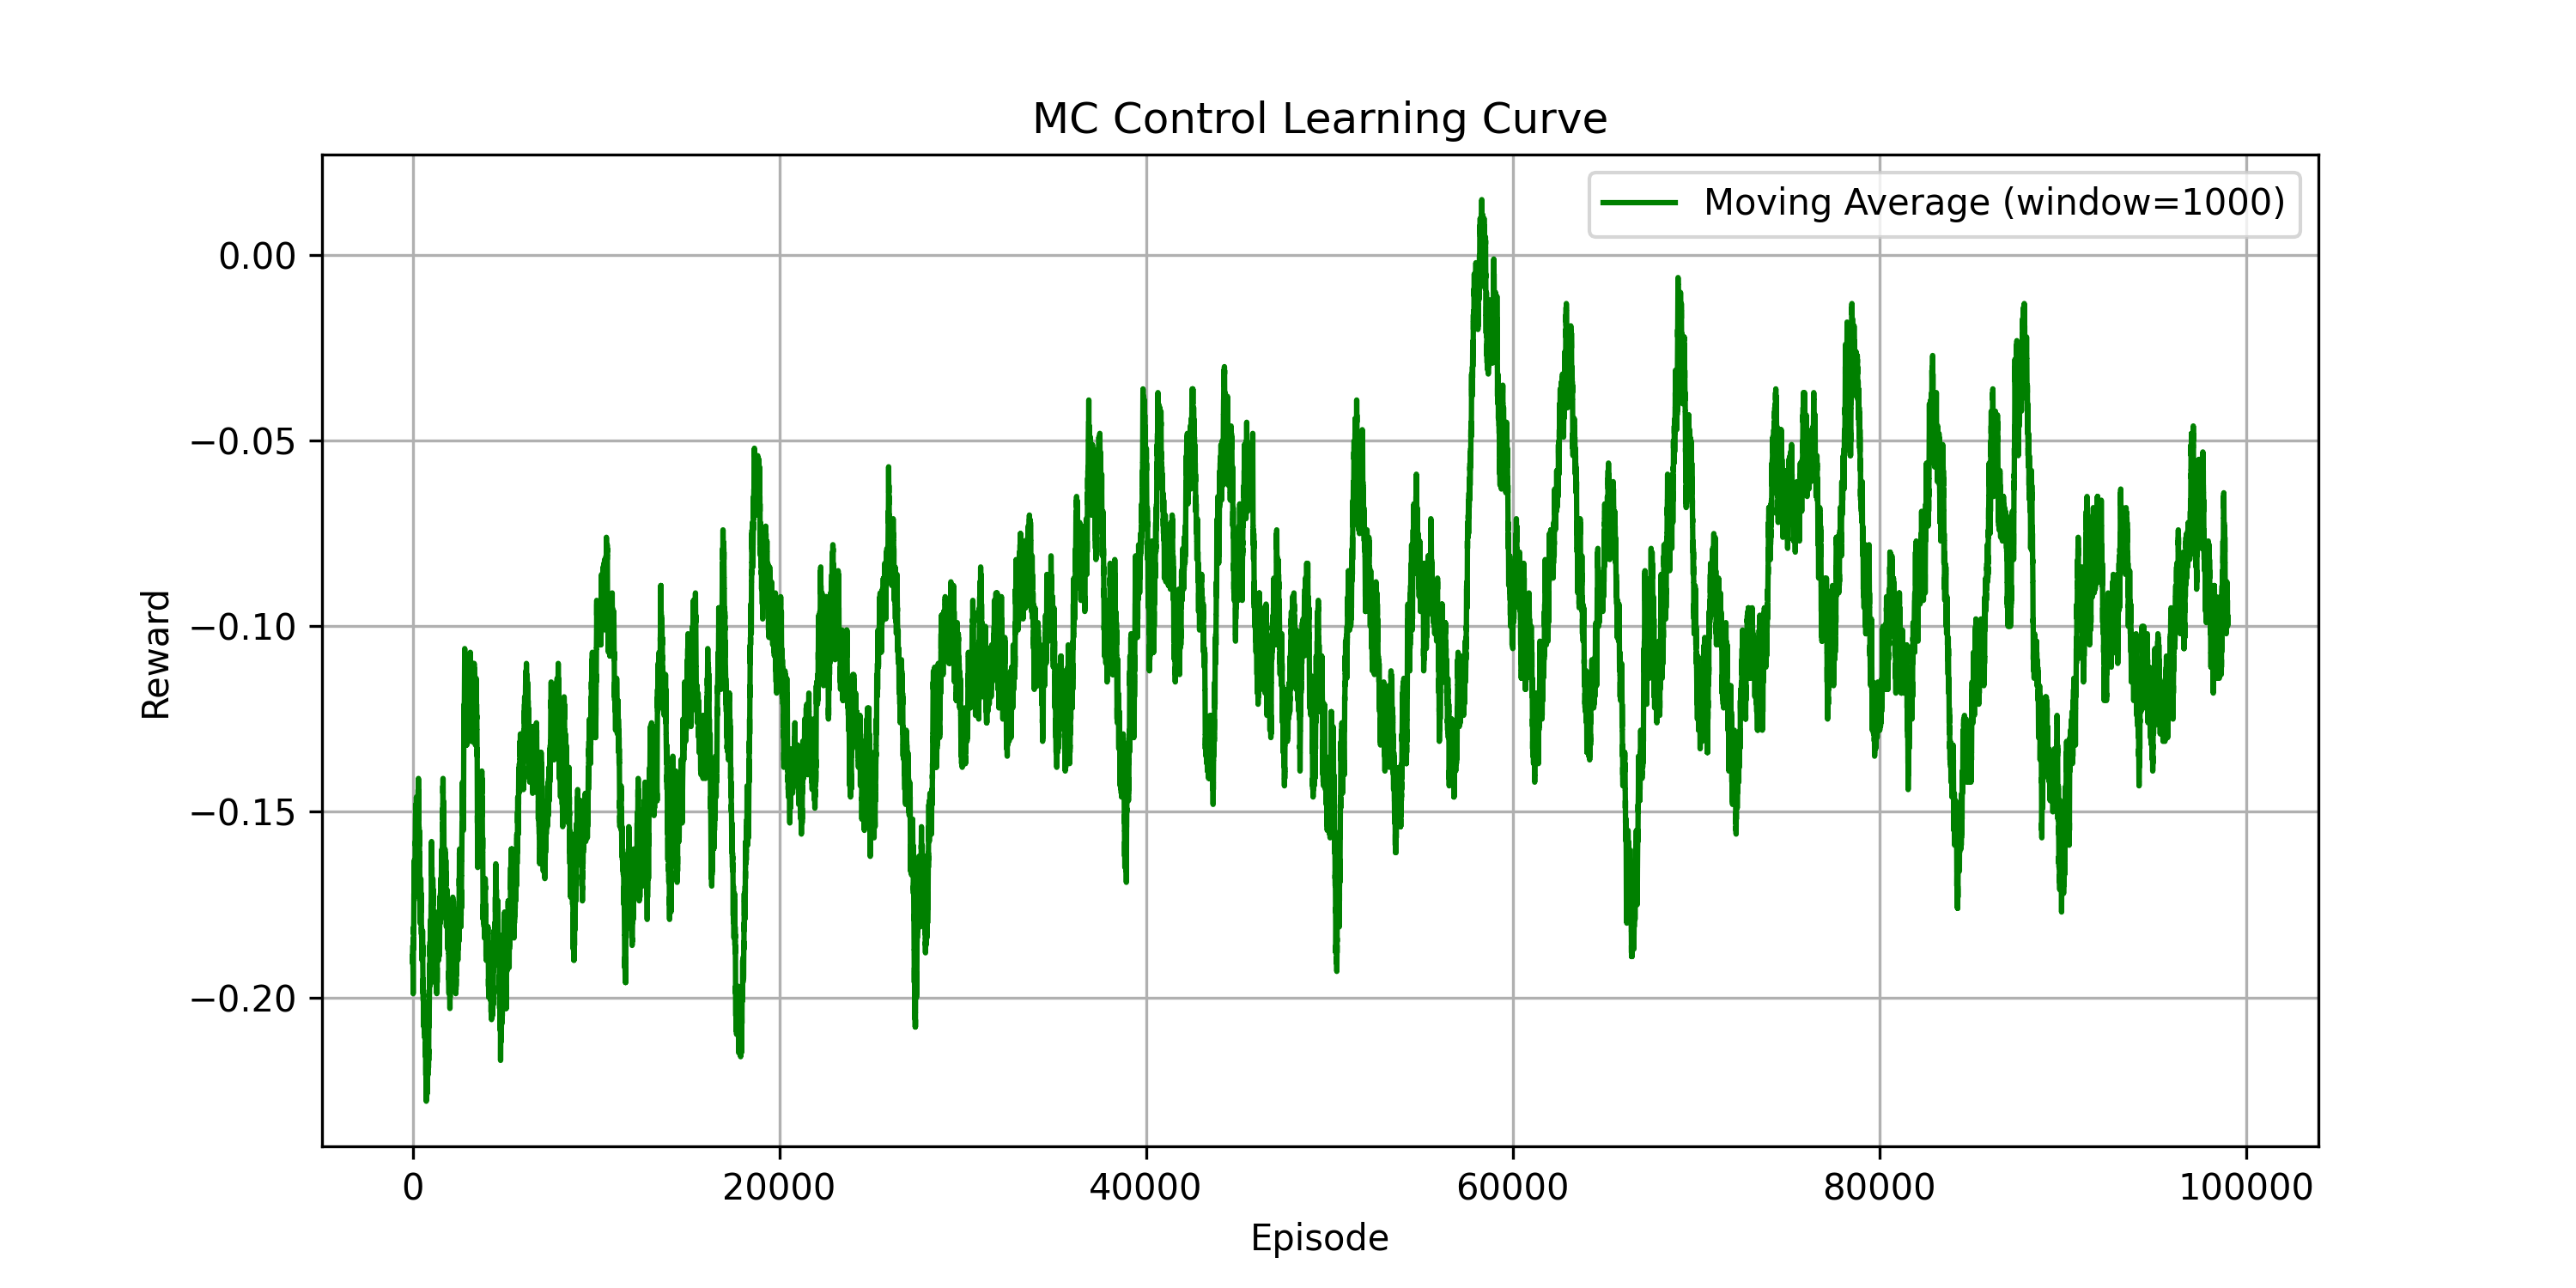

In [30]:
import os

file_path = os.path.join(".", "src", "bai35.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 35: Learning curve"""
import os
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from mc_utils import on_policy_mc_control

def main():
    env = gym.make("Blackjack-v1")
    _, _, rewards = on_policy_mc_control(env, n_episodes=100000, seed=42)
    
    window = 1000
    moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
    
    fig_dir = os.path.join("Lab03", "figures")
    os.makedirs(fig_dir, exist_ok=True)
    
    plt.figure(figsize=(10, 5))
    plt.plot(moving_avg, color='g', label=f"Moving Average (window={window})")
    plt.title("MC Control Learning Curve")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.grid(True)
    plt.legend()
    
    output_path = os.path.join(fig_dir, "mc_convergence.png")
    plt.savefig(output_path, dpi=300)
    plt.close()
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

from IPython.display import Image, display
display(Image(filename="Lab03/figures/mc_convergence.png"))

## **Bài Tập Phần Mini - Project Và Tự Chọn**

### **Bài 36. Monte Carlo Agent hoàn chỉnh**
Xây dựng chương trình Monte Carlo Agent hoàn chỉnh tổng hợp toàn bộ quy trình từ khởi tạo môi trường, dự đoán (MC Prediction), tối ưu (MC Control) đến đánh giá và kết luận.

**Mục đích:** Tổng hợp trọn vẹn quy trình xây dựng, huấn luyện, đánh giá và rút ra nhận xét/kết luận về thuật toán Monte Carlo Agent trên môi trường Gymnasium (Blackjack-v1).

1. Environment: Blackjack-v1
2. Observation space: Tuple(Discrete(32), Discrete(11), Discrete(2))
   Action space: Discrete(2)
3. Episode mẫu:
   State: (15, 2, 0), Action: 1, Reward: -1.0
4. Trajectory: [((15, 2, 0), 1)]
5. Reward: [-1.0]
6. Return (gamma=1.0): [-1.0]
7. Discounted return (gamma=0.9): [-1.0]
8. Fixed policy: Stick on 20
9. First-Visit MC Prediction (Số states: 278)
10. Every-Visit MC Prediction (Số states: 278)
11. So sánh hai prediction method (Mean abs diff: 0.000000)
12. Q(s,a) đã tính toán cho 280 states
13. Epsilon-greedy (epsilon = 0.1)
14. On-policy MC Control hoàn tất qua 50000 episodes
15. Training curve đã lưu tại: Lab03\figures\bai36_mc_agent_training.png
16. Learned policy cho một số state mẫu:
    State (20, 10, False): Action = 0
    State (18, 6, False): Action = 0
    State (13, 2, False): Action = 0
    State (18, 6, True): Action = 0
17 & 18. Evaluation và So sánh Policy:
    Random Policy        | Win: 0.2830 | Loss: 0.6768 | Draw: 0.0402 | Mean Rew

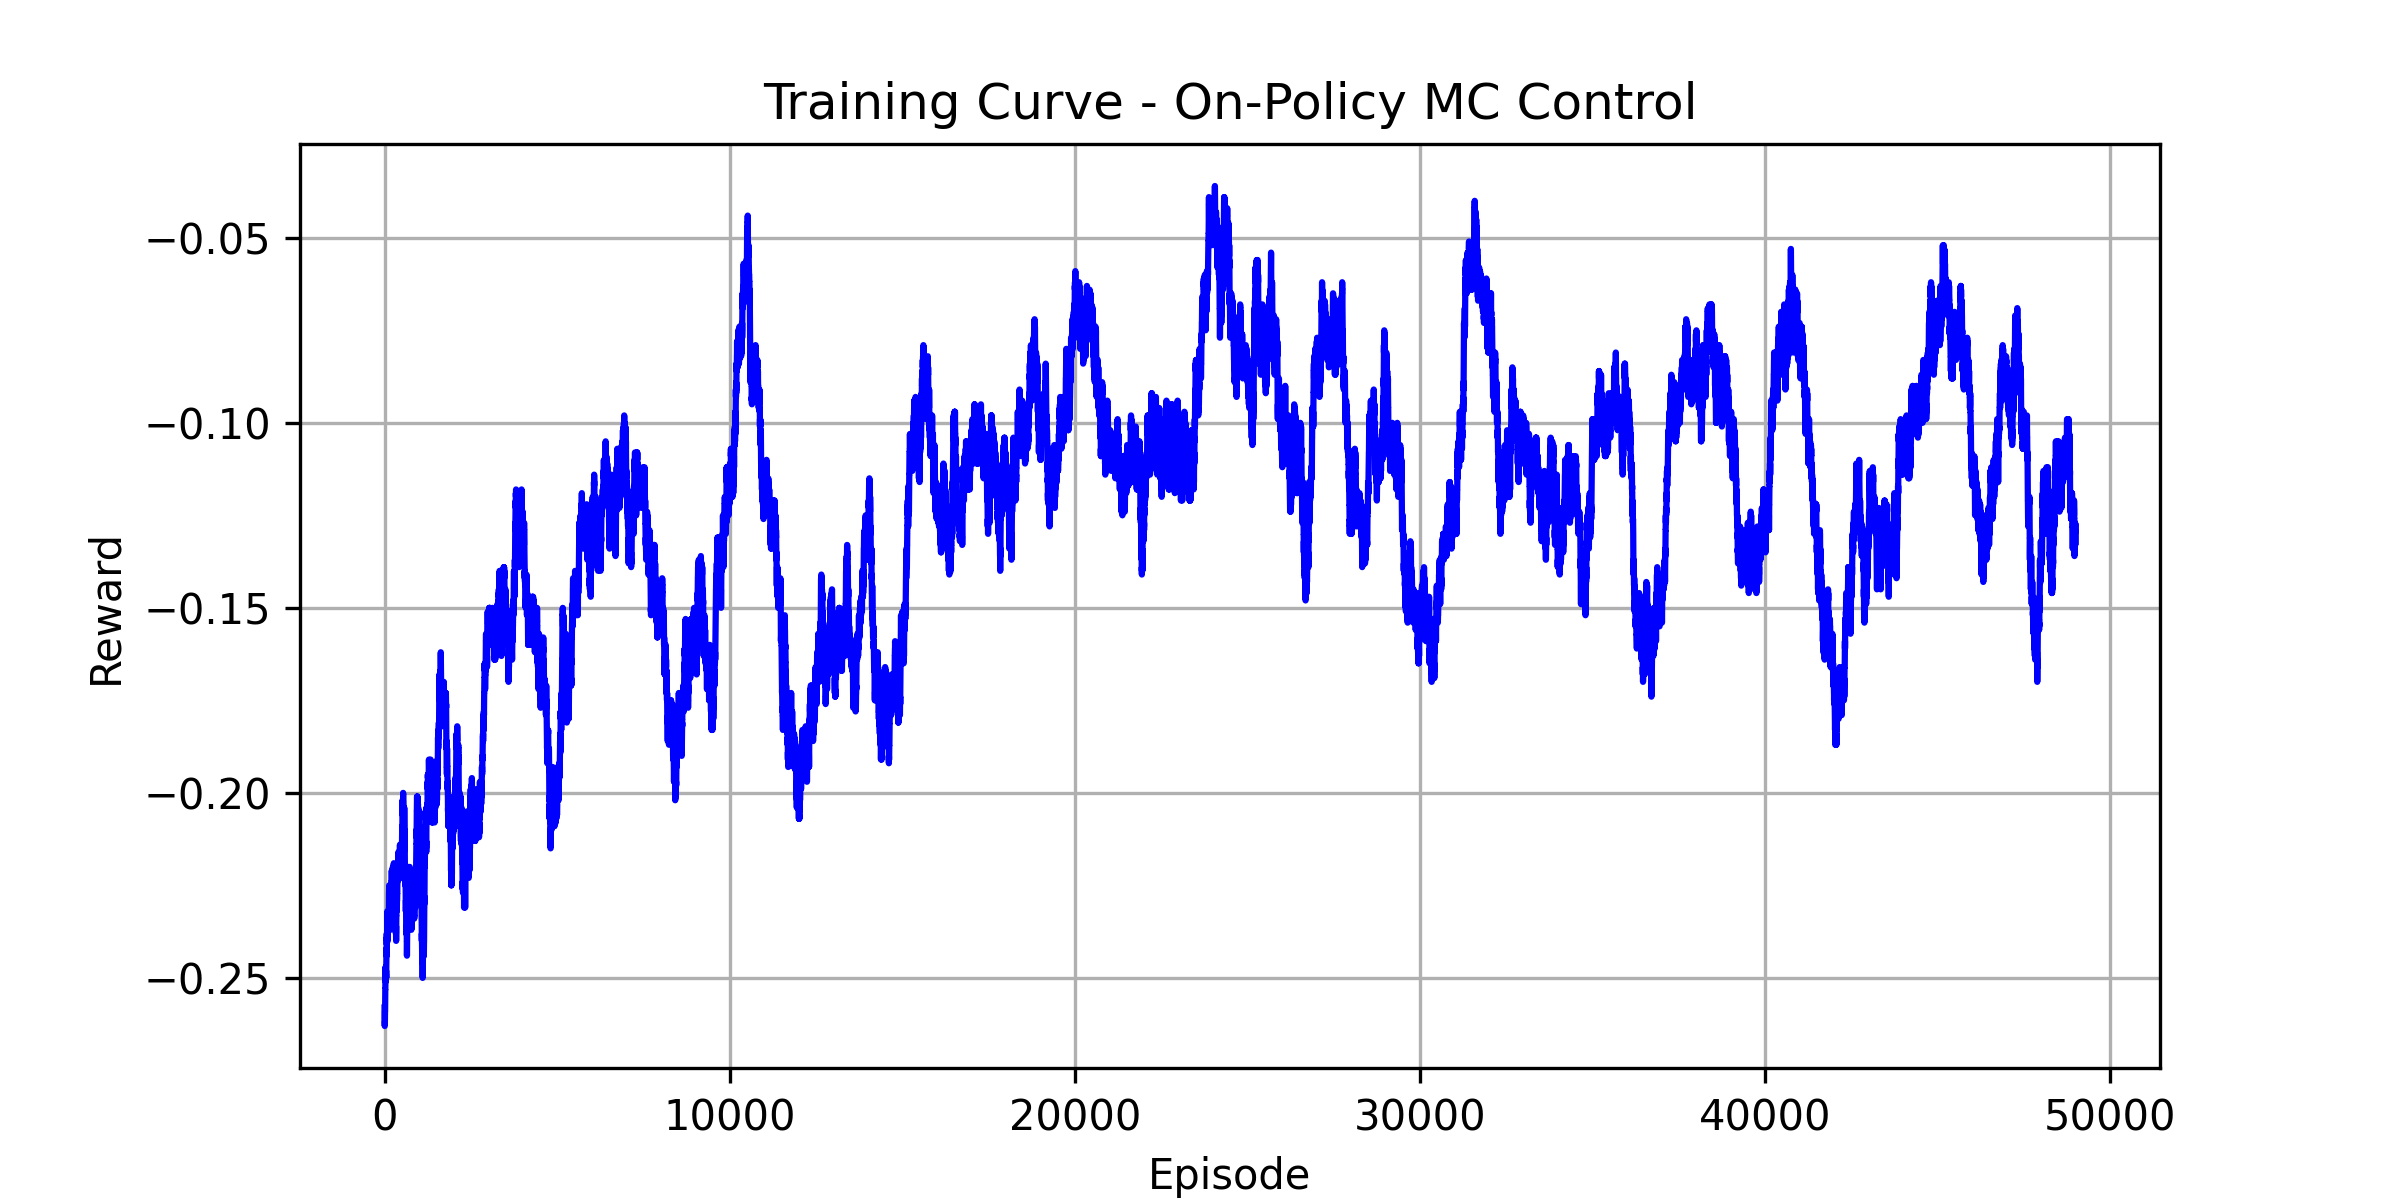

In [32]:
import os

file_path = os.path.join(".", "src", "main.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Bài 36: Monte Carlo Agent hoàn chỉnh"""
import os
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def stick_on_20_policy(state):
    player_sum, _, _ = state
    return 0 if player_sum >= 20 else 1

def generate_episode(env, policy, seed=None):
    episode = []
    state, _ = env.reset(seed=seed)
    done = False
    while not done:
        action = policy(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        episode.append((state, action, reward))
        state = next_state
    return episode

def compute_returns(rewards, gamma=1.0):
    G = 0.0
    returns = [0.0] * len(rewards)
    for t in reversed(range(len(rewards))):
        G = rewards[t] + gamma * G
        returns[t] = G
    return returns

def first_visit_mc_prediction(env, policy, n_episodes, gamma=1.0):
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)
    for ep_idx in range(n_episodes):
        ep = generate_episode(env, policy, seed=ep_idx)
        rewards = [step[2] for step in ep]
        g_list = compute_returns(rewards, gamma=gamma)
        visited_states = set()
        for idx, step in enumerate(ep):
            st = step[0]
            if st not in visited_states:
                visited_states.add(st)
                returns_sum[st] += g_list[idx]
                returns_count[st] += 1
    return {st: returns_sum[st] / returns_count[st] for st in returns_sum}

def every_visit_mc_prediction(env, policy, n_episodes, gamma=1.0):
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)
    for ep_idx in range(n_episodes):
        ep = generate_episode(env, policy, seed=ep_idx)
        rewards = [step[2] for step in ep]
        g_list = compute_returns(rewards, gamma=gamma)
        for idx, step in enumerate(ep):
            st = step[0]
            returns_sum[st] += g_list[idx]
            returns_count[st] += 1
    return {st: returns_sum[st] / returns_count[st] for st in returns_sum}

def epsilon_greedy_action(Q, state, n_actions, epsilon, rng):
    if rng.random() < epsilon:
        return rng.integers(0, n_actions)
    if state not in Q:
        return rng.integers(0, n_actions)
    return int(np.argmax(Q[state]))

def update_incremental_mean(Q, N, state, action, G):
    N[state][action] += 1
    Q[state][action] += (G - Q[state][action]) / N[state][action]

def greedy_action(Q, state, n_actions):
    if state not in Q:
        return 0
    return int(np.argmax(Q[state]))

def generate_episode_control(env, Q, epsilon, rng):
    episode = []
    state, _ = env.reset()
    done = False
    n_actions = env.action_space.n
    while not done:
        action = epsilon_greedy_action(Q, state, n_actions, epsilon, rng)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        episode.append((state, action, reward))
        state = next_state
    return episode

def on_policy_mc_control(env, n_episodes, gamma=1.0, epsilon=0.1, seed=42):
    rng = np.random.default_rng(seed)
    n_actions = env.action_space.n
    Q = defaultdict(lambda: np.zeros(n_actions))
    N = defaultdict(lambda: np.zeros(n_actions))
    episode_rewards = []
    for ep_idx in range(n_episodes):
        ep = generate_episode_control(env, Q, epsilon, rng)
        rewards = [step[2] for step in ep]
        episode_rewards.append(sum(rewards))
        g_list = compute_returns(rewards, gamma=gamma)
        visited_sa = set()
        for idx, step in enumerate(ep):
            st, act, _ = step
            sa = (st, act)
            if sa not in visited_sa:
                visited_sa.add(sa)
                update_incremental_mean(Q, N, st, act, g_list[idx])
    def policy(state):
        return greedy_action(Q, state, n_actions)
    return Q, policy, episode_rewards

def evaluate_policy(env, policy, n_episodes=10000, seed=123):
    wins, losses, draws = 0, 0, 0
    total_rewards = []
    for ep_idx in range(n_episodes):
        ep = generate_episode(env, policy=policy, seed=seed + ep_idx)
        final_r = ep[-1][2]
        total_rewards.append(final_r)
        if final_r == 1.0:
            wins += 1
        elif final_r == -1.0:
            losses += 1
        else:
            draws += 1
    return {
        "win_rate": wins / n_episodes,
        "loss_rate": losses / n_episodes,
        "draw_rate": draws / n_episodes,
        "mean_reward": np.mean(total_rewards)
    }

def main():
    env = gym.make("Blackjack-v1")
    print("1. Environment: Blackjack-v1")
    
    print(f"2. Observation space: {env.observation_space}")
    print(f"   Action space: {env.action_space}")
    
    sample_ep = generate_episode(env, stick_on_20_policy, seed=42)
    print("3. Episode mẫu:")
    for step in sample_ep:
        print(f"   State: {step[0]}, Action: {step[1]}, Reward: {step[2]}")
        
    trajectory = [(step[0], step[1]) for step in sample_ep]
    print(f"4. Trajectory: {trajectory}")
    
    rewards = [step[2] for step in sample_ep]
    print(f"5. Reward: {rewards}")
    
    returns_undiscounted = compute_returns(rewards, gamma=1.0)
    print(f"6. Return (gamma=1.0): {returns_undiscounted}")
    
    returns_discounted = compute_returns(rewards, gamma=0.9)
    print(f"7. Discounted return (gamma=0.9): {returns_discounted}")
    
    print("8. Fixed policy: Stick on 20")
    
    V_first = first_visit_mc_prediction(env, stick_on_20_policy, n_episodes=5000)
    print(f"9. First-Visit MC Prediction (Số states: {len(V_first)})")
    
    V_every = every_visit_mc_prediction(env, stick_on_20_policy, n_episodes=5000)
    print(f"10. Every-Visit MC Prediction (Số states: {len(V_every)})")
    
    common_states = set(V_first.keys()).intersection(set(V_every.keys()))
    diffs = [abs(V_first[st] - V_every[st]) for st in common_states]
    print(f"11. So sánh hai prediction method (Mean abs diff: {np.mean(diffs):.6f})")
    
    n_train_episodes = 50000
    Q, learned_policy, episode_rewards = on_policy_mc_control(env, n_episodes=n_train_episodes, epsilon=0.1, seed=42)
    print(f"12. Q(s,a) đã tính toán cho {len(Q)} states")
    print("13. Epsilon-greedy (epsilon = 0.1)")
    print(f"14. On-policy MC Control hoàn tất qua {n_train_episodes} episodes")
    
    fig_dir = os.path.join("Lab03", "figures")
    os.makedirs(fig_dir, exist_ok=True)
    window = 1000
    moving_avg = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    
    plt.figure(figsize=(8, 4))
    plt.plot(moving_avg, color='b')
    plt.title("Training Curve - On-Policy MC Control")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.grid(True)
    plot_path = os.path.join(fig_dir, "bai36_mc_agent_training.png")
    plt.savefig(plot_path, dpi=300)
    plt.close()
    print(f"15. Training curve đã lưu tại: {plot_path}")
    
    print("16. Learned policy cho một số state mẫu:")
    for st in [(20, 10, False), (18, 6, False), (13, 2, False), (18, 6, True)]:
        print(f"    State {st}: Action = {learned_policy(st)}")
        
    def random_policy(state):
        return env.action_space.sample()
        
    policies = {
        "Random Policy": random_policy,
        "Fixed Policy": stick_on_20_policy,
        "Learned MC Policy": learned_policy
    }
    
    print("17 & 18. Evaluation và So sánh Policy:")
    for name, pol in policies.items():
        res = evaluate_policy(env, pol, n_episodes=10000, seed=123)
        print(f"    {name:<20} | Win: {res['win_rate']:.4f} | Loss: {res['loss_rate']:.4f} | Draw: {res['draw_rate']:.4f} | Mean Reward: {res['mean_reward']:.4f}")
        
    print("19. Nhận xét: Learned Policy tối ưu tỷ lệ thắng và phần thưởng trung bình so với các policy còn lại.")
    print("20. Kết luận: Thuật toán Monte Carlo Control học thành công chiến lược tối ưu mà không cần thông tin chuyển trạng thái của môi trường.")
    
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

from IPython.display import Image, display
display(Image(filename="Lab03/figures/bai36_mc_agent_training.png"))

### **Mở rộng 1: Off-Policy Monte Carlo**

1. KHÁI NIỆM CỐT LÕI OFF-POLICY MONTE CARLO
   - Target Policy (pi): Chính sách mục tiêu cần tối ưu hóa (thường là Greedy policy).
   - Behavior Policy (b): Chính sách hành vi dùng để thám hiểm và thu thập dữ liệu (thường là Epsilon-greedy policy).
   - Importance Sampling: Kỹ thuật hiệu chỉnh trọng số xác suất khi học dữ liệu được tạo ra bởi một chính sách khác.

2. Huấn luyện Off-policy MC Control với 50000 episodes...
   Đã học xong Q-table với 280 states.

3. Kiểm tra Target Policy thu được tại một số state mẫu:
   State (20, 10, False): Action = 0 (Stick)
   State (18, 6, False): Action = 0 (Stick)
   State (13, 2, False): Action = 1 (Hit)
   State (18, 6, True): Action = 0 (Stick)

4. Đánh giá Target Policy (10,000 episodes):
   Win Rate: 0.4286 | Loss Rate: 0.4890 | Draw Rate: 0.0824 | Mean Reward: -0.0604

5. Training curve đã lưu tại: Lab03\figures\off_policy_mc_control.png


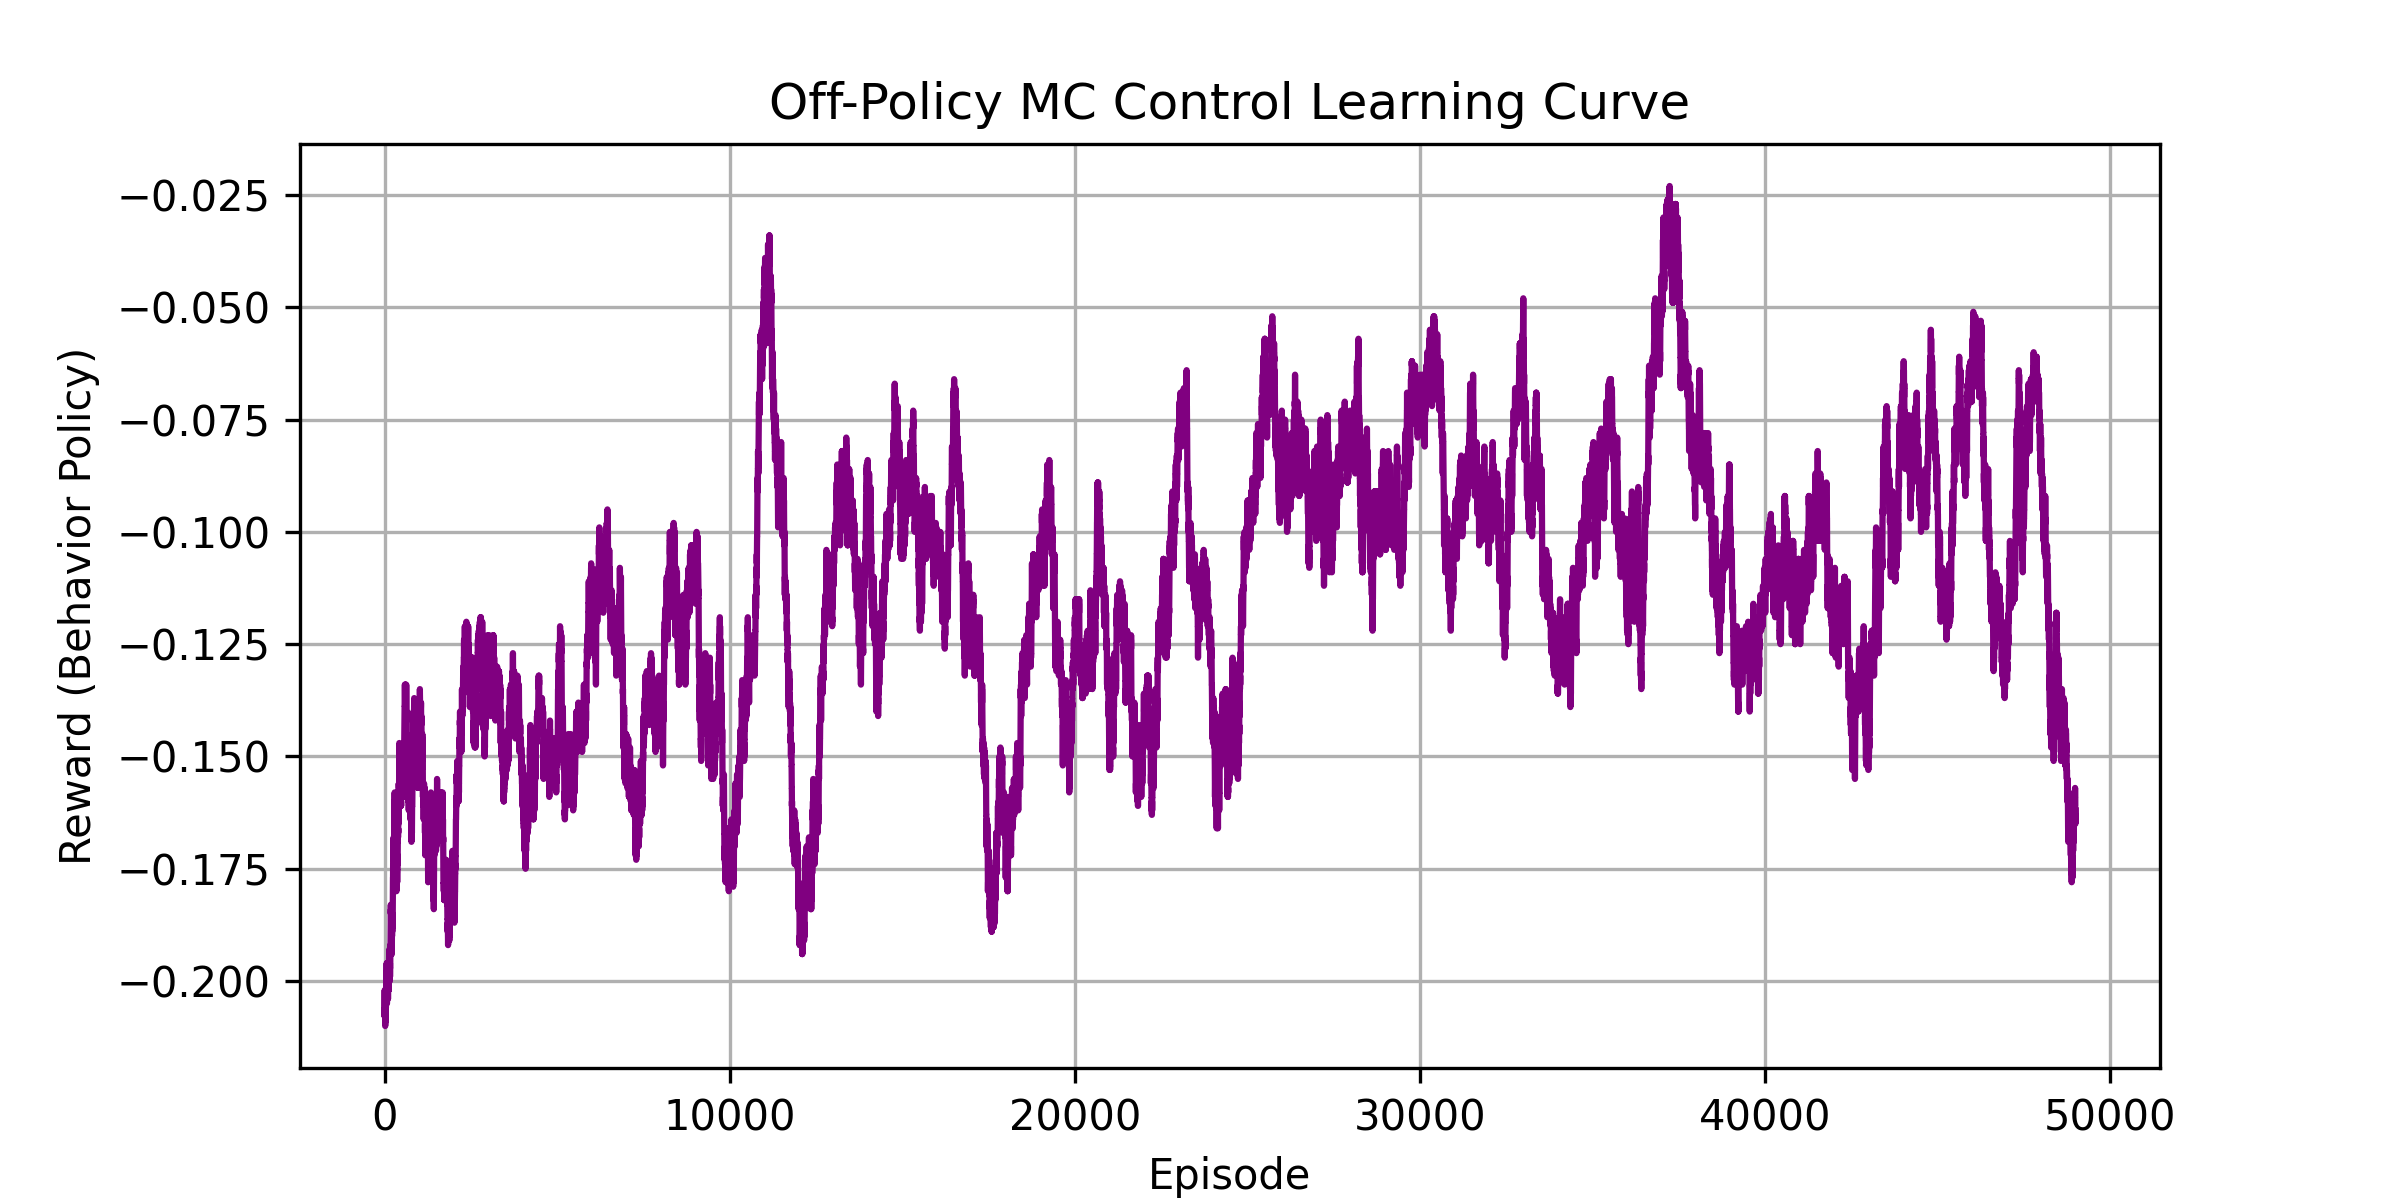

In [33]:
import os

file_path = os.path.join(".", "src", "off_policy_mc.py")
os.makedirs(os.path.dirname(file_path), exist_ok=True)

code_content = '''"""Mở rộng 1: Off-policy Monte Carlo Control (Weighted Importance Sampling)"""
import os
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from mc_utils import compute_returns, evaluate_policy

def create_behavior_policy(Q, epsilon, n_actions):
    def policy_probs(state):
        probs = np.ones(n_actions, dtype=float) * (epsilon / n_actions)
        best_action = np.argmax(Q[state]) if state in Q else 0
        probs[best_action] += (1.0 - epsilon)
        return probs
    return policy_probs

def off_policy_mc_control(env, n_episodes, gamma=1.0, epsilon=0.1, seed=42):
    rng = np.random.default_rng(seed)
    n_actions = env.action_space.n
    
    Q = defaultdict(lambda: np.zeros(n_actions))
    C = defaultdict(lambda: np.zeros(n_actions))
    
    target_policy = lambda state: int(np.argmax(Q[state])) if state in Q else 0
    episode_rewards = []
    
    for ep_idx in range(n_episodes):
        behavior_policy = create_behavior_policy(Q, epsilon, n_actions)
        
        episode = []
        state, _ = env.reset(seed=int(rng.integers(0, 1e6)))
        done = False
        
        while not done:
            probs = behavior_policy(state)
            action = rng.choice(n_actions, p=probs)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode.append((state, action, reward))
            state = next_state
            
        rewards = [step[2] for step in episode]
        episode_rewards.append(sum(rewards))
        
        G = 0.0
        W = 1.0
        
        for t in reversed(range(len(episode))):
            st, act, reward = episode[t]
            G = gamma * G + reward
            
            C[st][act] += W
            Q[st][act] += (W / C[st][act]) * (G - Q[st][act])
            
            if act != target_policy(st):
                break
                
            probs = behavior_policy(st)
            W = W * (1.0 / probs[act])
            
    return Q, target_policy, episode_rewards

def main():
    print("1. KHÁI NIỆM CỐT LÕI OFF-POLICY MONTE CARLO")
    print("   - Target Policy (pi): Chính sách mục tiêu cần tối ưu hóa (thường là Greedy policy).")
    print("   - Behavior Policy (b): Chính sách hành vi dùng để thám hiểm và thu thập dữ liệu (thường là Epsilon-greedy policy).")
    print("   - Importance Sampling: Kỹ thuật hiệu chỉnh trọng số xác suất khi học dữ liệu được tạo ra bởi một chính sách khác.")
    
    env = gym.make("Blackjack-v1")
    n_episodes = 50000
    print(f"\\n2. Huấn luyện Off-policy MC Control với {n_episodes} episodes...")
    
    Q, target_policy, episode_rewards = off_policy_mc_control(env, n_episodes=n_episodes, gamma=1.0, epsilon=0.1, seed=42)
    print(f"   Đã học xong Q-table với {len(Q)} states.")
    
    print("\\n3. Kiểm tra Target Policy thu được tại một số state mẫu:")
    for st in [(20, 10, False), (18, 6, False), (13, 2, False), (18, 6, True)]:
        act = target_policy(st)
        act_str = "Stick" if act == 0 else "Hit"
        print(f"   State {st}: Action = {act} ({act_str})")
        
    print("\\n4. Đánh giá Target Policy (10,000 episodes):")
    res = evaluate_policy(env, target_policy, n_episodes=10000, seed=123)
    print(f"   Win Rate: {res['win_rate']:.4f} | Loss Rate: {res['loss_rate']:.4f} | Draw Rate: {res['draw_rate']:.4f} | Mean Reward: {res['mean_reward']:.4f}")
    
    fig_dir = os.path.join("Lab03", "figures")
    os.makedirs(fig_dir, exist_ok=True)
    window = 1000
    moving_avg = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
    
    plt.figure(figsize=(8, 4))
    plt.plot(moving_avg, color='purple')
    plt.title("Off-Policy MC Control Learning Curve")
    plt.xlabel("Episode")
    plt.ylabel("Reward (Behavior Policy)")
    plt.grid(True)
    plot_path = os.path.join(fig_dir, "off_policy_mc_control.png")
    plt.savefig(plot_path, dpi=300)
    plt.close()
    print(f"\\n5. Training curve đã lưu tại: {plot_path}")
    
    env.close()

if __name__ == "__main__":
    main()
'''

with open(file_path, "w", encoding="utf-8") as f:
    f.write(code_content)

!python "{file_path}"

from IPython.display import Image, display
display(Image(filename="Lab03/figures/off_policy_mc_control.png"))

## **Trả Lời Câu Hỏi**

1. Monte Carlo method trong RL là gì?

   Là phương pháp học trong Reinforcement Learning dựa trên việc lấy mẫu (sampling) các trải nghiệm (episodes) hoàn chỉnh để ước lượng hàm giá trị ($V(s)$ hoặc $Q(s,a)$) và tìm chính sách tối ưu bằng cách lấy trung bình các phần thưởng tích lũy (Return $G_t$).
2. Vì sao Monte Carlo được gọi là model-free?

   Vì MC không cần biết trước mô hình toán học của môi trường (không cần hàm xác suất chuyển trạng thái $P(s'\vert{}s,a)$ hay hàm phần thưởng $R$). Agent học trực tiếp thông qua việc tương tác và thu thập các mẫu dữ liệu thực tế từ môi trường.

3. Vì sao Monte Carlo cần episodic task?

   Vì MC tính Return $G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$ dựa trên phần thưởng tích lũy cho tới khi episode kết thúc (Terminal state). Nếu nhiệm vụ kéo dài vô hạn (continuing task), MC không thể đợi đến khi kết thúc để tính $G_t$.

4. Episode khác trajectory như thế nào trong bài này?

   * Episode: Là một chuỗi tương tác trọn vẹn từ trạng thái bắt đầu (Start State) đến trạng thái kết thúc (Terminal State): $S_0, A_0, R_1, S_1, A_1, \dots, S_T$.
   * Trajectory: Là một đường đi / quỹ đạo chuyển trạng thái ngẫu nhiên, có thể là trọn vẹn một episode hoặc chỉ là một phân đoạn nhỏ từ bước $t_1$ đến $t_2$.

5. Return được tính khi nào?

   Return ($G_t$) chỉ được tính khi episode đã kết thúc hoàn toàn, bằng cách duyệt ngược (backward) từ bước cuối cùng $T$ về bước $t$.

6. Monte Carlo Prediction dùng để làm gì?

   Dùng để đánh giá chính sách (Policy Evaluation) — tức là ước lượng hàm giá trị trạng thái $V^\pi(s)$ hoặc hàm giá trị hành động $Q^\pi(s,a)$ cho một chính sách $\pi$ cố định cho trước.

7. First-Visit MC khác Every-Visit MC thế nào?

   * First-Visit MC: Chỉ tính và tích lũy Return $G_t$ cho lần xuất hiện đầu tiên của trạng thái $s$ (hoặc cặp $(s,a)$) trong một episode.
   * Every-Visit MC: Tích lũy Return $G_t$ cho tất cả các lần xuất hiện của trạng thái $s$ (hoặc cặp $(s,a)$) trong cùng một episode.

8. Vì sao phải lấy trung bình nhiều return?

   Do tính ngẫu nhiên của môi trường và chính sách, Return $G_t$ từ một episode đơn lẻ chứa nhiều nhiễu (variance). Theo Luật số lớn (Law of Large Numbers), lấy trung bình của nhiều Return qua nhiều episode giúp giá trị ước lượng hội tụ về giá trị kỳ vọng thực sự $E_\pi[G_t \vert{} S_t = s]$.

9. Khi số episode tăng, estimate V(s) thay đổi như thế nào?

   Độ lệch/nhiễu giảm dần, giá trị ước lượng $V(s)$ trở nên ổn định hơn và hội tụ chính xác về giá trị thực $V^\pi(s)$.

10. V(s) khác Q(s,a) thế nào?

   * $V(s)$ (State-value): Giá trị kỳ vọng nhận được khi bắt đầu từ trạng thái $s$ và tuân theo chính sách $\pi$.
   * $Q(s,a)$ (Action-value): Giá trị kỳ vọng nhận được khi bắt đầu từ trạng thái $s$, thực hiện hành động cụ thể $a$, sau đó mới tuân theo chính sách $\pi$.

11. Vì sao MC control cần Q(s,a) thay vì chỉ V(s)?

    Vì MC là phương pháp model-free (không biết xác suất chuyển trạng thái $P(s'\vert{}s,a)$). Nếu chỉ có $V(s)$, agent không biết hành động nào sẽ dẫn tới trạng thái tốt hơn. Với $Q(s,a)$, agent chỉ cần chọn hành động $\arg\max_a Q(s,a)$ mà không cần mô hình môi trường.

12. Exploration là gì?

    Là việc agent thử nghiệm các hành động mới hoặc chưa được khám phá kỹ để thu thập thêm thông tin về môi trường, tránh bỏ lỡ chiến lược tốt hơn.

13. Exploitation là gì?

    Là việc agent tận dụng những kiến thức/giá trị tốt nhất hiện có để chọn hành động nhằm tối đa hóa phần thưởng ngay lập tức.

14. Epsilon-greedy cân bằng exploration/exploitation thế nào?

    * Sử dụng tham số $\epsilon \in [0,1]$:Với xác suất $1 - \epsilon$: Exploitation (chọn hành động tốt nhất hiện tại $\arg\max_a Q(s,a)$).
    * Với xác suất $\epsilon$: Exploration (chọn ngẫu nhiên một hành động bất kỳ).

15. Khi epsilon quá lớn thì có vấn đề gì?

    Agent chọn hành động ngẫu nhiên quá nhiều (thám hiểm quá đà), làm cho chính sách không hội tụ được về chiến lược tối ưu và thu được phần thưởng trung bình rất thấp.

16. Khi epsilon quá nhỏ từ đầu thì có vấn đề gì?

    Agent tham lam quá sớm (Exploitation sớm), không khám phá đủ không gian trạng thái/hành động, dễ bị kẹt vào chiến lược tối ưu cục bộ (local optima) kém hiệu quả.

17. Incremental mean có lợi gì so với lưu toàn bộ returns?

    * Tiết kiệm bộ nhớ: Không cần lưu danh sách hàng triệu Return cũ.
    * Tối ưu tính toán: Cập nhật công thức trung bình tăng dần cực nhanh: $Q \leftarrow Q + \frac{1}{N}(G - Q)$.

18. On-policy MC control nghĩa là gì?

    Nghĩa là thuật toán đánh giá và cải thiện chính chính sách đang được dùng để thu thập dữ liệu episode (ở đây là chính sách $\epsilon$-greedy).

19. Policy dùng để sinh episode có thay đổi trong quá trình học không?

    Có. Trong quá trình học, sau mỗi episode (hoặc mỗi chu kỳ), chính sách sinh episode được cập nhật liên tục dựa trên bảng giá trị $Q(s,a)$ mới tính toán.

20. Monte Carlo có bootstrap không?

    Không. Monte Carlo cập nhật giá trị dựa trên Return thực tế trọn vẹn $G_t$ tới cuối episode, không dùng ước lượng của trạng thái tiếp theo để cập nhật trạng thái hiện tại.

21. MC phải đợi đến cuối episode vì sao?

    Vì MC bắt buộc phải có đầy đủ phần thưởng thực tế của tất cả các bước cho tới điểm kết thúc để tính chính xác $G_t = R_{t+1} + \gamma R_{t+2} + \dots + \gamma^{T-t-1} R_T$.

22. Random policy và learned policy khác nhau ra sao về mean reward?

    * Random policy: Mean reward rất thấp (thường âm sâu, khoảng -0.35 đến -0.40 trong Blackjack) do rút bài ngẫu nhiên dẫn tới đền bài (bust) thường xuyên.
    * Learned policy: Mean reward cao hơn rõ rệt (tiệm cận mức tối ưu khoảng -0.05 đến -0.04 trong Blackjack) nhờ biết dừng/rút bài hợp lý theo điểm số.

23. Learned policy có chắc chắn tối ưu không? Vì sao?

    Trong thực tế không chắc chắn 100% tuyệt đối, vì số lượng episode huấn luyện luôn có hạn và $\epsilon > 0$ vẫn tạo ra sai số nhỏ. Tuy nhiên, về mặt lý thuyết, khi số episode tiến tới vô hạn và thỏa mãn điều kiện GLIE (Greedy in the Limit with Infinite Exploration), nó đảm bảo hội tụ về chính sách tối ưu.

24. Số episode ảnh hưởng chất lượng estimate thế nào?

    Số episode càng nhiều thì độ biến động (variance) càng giảm, ước lượng giá trị $V(s)$ và $Q(s,a)$ càng chính xác, giúp chính sách hội tụ ổn định hơn.

25. Monte Carlo khác Dynamic Programming ở điểm quan trọng nào?
    * Mô hình môi trường: DP yêu cầu phải biết trước mô hình $P(s'\vert{}s,a)$ và $R$, còn MC là model-free (chỉ cần lấy mẫu).
    * Bootstrapping: DP sử dụng Bootstrapping (cập nhật từ ước lượng trạng thái kế tiếp), còn MC cập nhật từ Return thực tế trọn vẹn $G_t$.
    * Phạm vi cập nhật: DP quét và cập nhật toàn bộ không gian trạng thái (full sweep), còn MC chỉ cập nhật các trạng thái thực sự xuất hiện trong episode.